In [62]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

for file_path in Path("/content/drive/MyDrive").rglob("*.csv"):
    print(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/heart_disease_clinical_analysis/dataset_source_registry.csv
/content/drive/MyDrive/heart_disease_clinical_analysis/data_loading_report.csv
/content/drive/MyDrive/heart_disease_clinical_analysis/cleaned_heart_data.csv
/content/drive/MyDrive/heart_disease_clinical_analysis/cleaning_report.csv
/content/drive/MyDrive/heart_disease_clinical_analysis/train_raw.csv
/content/drive/MyDrive/heart_disease_clinical_analysis/validation_raw.csv
/content/drive/MyDrive/heart_disease_clinical_analysis/test_raw.csv
/content/drive/MyDrive/heart_disease_clinical_analysis/split_class_distribution.csv
/content/drive/MyDrive/heart_disease_clinical_analysis/split_summary.csv
/content/drive/MyDrive/heart_disease_clinical_analysis/resampling_decision.csv
/content/drive/MyDrive/heart_disease_clinical_analysis/train_model_ready.csv
/content/drive/MyDrive/heart_dis

In [63]:
from pathlib import Path

DATA_FILE = Path(
    "/content/heart.csv"
)

print("Dataset path:", DATA_FILE)
print("File exists:", DATA_FILE.is_file())

Dataset path: /content/heart.csv
File exists: True


## Step 1: Dataset Configuration and Source Registration

In [64]:
from pathlib import Path
from IPython.display import display

import math
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# A. Dataset and output paths
# ------------------------------------------------------------

DATASET_DISPLAY_NAME = "Heart Diseases 02"

DATA_FILE = Path(
    "/content/heart.csv"
)

DATASET_DIR = DATA_FILE.parent

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/heart_disease_clinical_analysis"
)

EDA_DIR = OUTPUT_DIR / "eda"


EXPECTED_COLUMNS = [
    "Age",
    "Sex",
    "ChestPainType",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "RestingECG",
    "MaxHR",
    "ExerciseAngina",
    "Oldpeak",
    "ST_Slope",
    "HeartDisease",
]


# ------------------------------------------------------------
# B. Verify dataset location
# ------------------------------------------------------------

if not DATA_FILE.is_file():
    raise FileNotFoundError(
        f"Dataset file was not found:\n{DATA_FILE}"
    )


# ------------------------------------------------------------
# C. Create output directories
# ------------------------------------------------------------

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

EDA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# D. Verify CSV columns
# ------------------------------------------------------------

header_df = pd.read_csv(
    DATA_FILE,
    nrows=0,
)

header_columns = [
    str(column).strip()
    for column in header_df.columns
]

missing_columns = sorted(
    set(EXPECTED_COLUMNS).difference(
        header_columns
    )
)

unexpected_columns = sorted(
    set(header_columns).difference(
        EXPECTED_COLUMNS
    )
)

if missing_columns or unexpected_columns:
    raise ValueError(
        "The CSV does not match the expected heart-disease schema.\n"
        f"Missing columns    : {missing_columns}\n"
        f"Unexpected columns : {unexpected_columns}"
    )


# ------------------------------------------------------------
# E. Source registration
# ------------------------------------------------------------

SOURCE_ID = "heart_diseases_02"
SOURCE_NAME = DATASET_DISPLAY_NAME
SOURCE_TYPE = "single_aggregated_clinical_csv"
HOSPITAL_IDENTIFIER_AVAILABLE = False


dataset_source_registry_df = pd.DataFrame(
    [
        {
            "source_id": SOURCE_ID,
            "source_name": SOURCE_NAME,
            "source_type": SOURCE_TYPE,
            "file_name": DATA_FILE.name,
            "configured_dataset_directory": str(
                DATASET_DIR
            ),
            "configured_file_path": str(
                DATA_FILE
            ),
            "file_size_kb": round(
                DATA_FILE.stat().st_size / 1024,
                2,
            ),
            "hospital_identifier_available": (
                HOSPITAL_IDENTIFIER_AVAILABLE
            ),
        }
    ]
)


dataset_source_registry_df.to_csv(
    OUTPUT_DIR / "dataset_source_registry.csv",
    index=False,
)


# ------------------------------------------------------------
# F. Display configured source
# ------------------------------------------------------------

print("Dataset configuration completed.")
print(f"Dataset name     : {DATASET_DISPLAY_NAME}")
print(f"Dataset directory: {DATASET_DIR}")
print(f"Dataset file     : {DATA_FILE}")
print(f"File exists      : {DATA_FILE.exists()}")
print(f"Output directory : {OUTPUT_DIR}")
print(f"EDA directory    : {EDA_DIR}")

display(
    dataset_source_registry_df
)

Dataset configuration completed.
Dataset name     : Heart Diseases 02
Dataset directory: /content
Dataset file     : /content/heart.csv
File exists      : True
Output directory : /content/drive/MyDrive/heart_disease_clinical_analysis
EDA directory    : /content/drive/MyDrive/heart_disease_clinical_analysis/eda


,source_id,source_name,source_type,file_name,configured_dataset_directory,configured_file_path,file_size_kb,hospital_identifier_available
0,heart_diseases_02,Heart Diseases 02,single_aggregated_clinical_csv,heart.csv,/content,/content/heart.csv,35.08,False


## Step 2: Data Loading and Schema Verification

In [65]:
# ------------------------------------------------------------
# A. Load dataset
# ------------------------------------------------------------

raw_clinical_df = pd.read_csv(
    DATA_FILE,
    low_memory=False,
)

raw_clinical_df.columns = (
    raw_clinical_df.columns
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# B. Validate exact schema
# ------------------------------------------------------------

missing_columns = sorted(
    set(EXPECTED_COLUMNS).difference(
        raw_clinical_df.columns
    )
)

unexpected_columns = sorted(
    set(raw_clinical_df.columns).difference(
        EXPECTED_COLUMNS
    )
)

if missing_columns or unexpected_columns:
    raise ValueError(
        "Dataset schema does not match the expected schema.\n"
        f"Missing columns    : {missing_columns}\n"
        f"Unexpected columns : {unexpected_columns}"
    )

raw_clinical_df = raw_clinical_df[
    EXPECTED_COLUMNS
].copy()


# ------------------------------------------------------------
# C. Add traceable record identifiers
# ------------------------------------------------------------

raw_clinical_df.insert(
    0,
    "source_row_number",
    np.arange(
        1,
        len(raw_clinical_df) + 1,
        dtype=np.int64,
    ),
)

raw_clinical_df.insert(
    0,
    "record_id",
    [
        f"heart_{row_number:06d}"
        for row_number in range(
            1,
            len(raw_clinical_df) + 1,
        )
    ],
)


# ------------------------------------------------------------
# D. Initial quality checks
# ------------------------------------------------------------

raw_missing_cells = int(
    raw_clinical_df[
        EXPECTED_COLUMNS
    ]
    .isna()
    .sum()
    .sum()
)

additional_duplicate_rows = int(
    raw_clinical_df
    .duplicated(
        subset=EXPECTED_COLUMNS,
        keep="first",
    )
    .sum()
)


# ------------------------------------------------------------
# E. Create and save loading report
# ------------------------------------------------------------

data_loading_report_df = pd.DataFrame(
    [
        {
            "source_id": SOURCE_ID,
            "file_name": DATA_FILE.name,
            "record_count": len(
                raw_clinical_df
            ),
            "clinical_column_count": len(
                EXPECTED_COLUMNS
            ),
            "raw_missing_cell_count": (
                raw_missing_cells
            ),
            "additional_duplicate_row_count": (
                additional_duplicate_rows
            ),
        }
    ]
)

data_loading_report_df.to_csv(
    OUTPUT_DIR / "data_loading_report.csv",
    index=False,
)


# ------------------------------------------------------------
# F. Display results
# ------------------------------------------------------------

print("Dataset loaded and schema verified successfully.")
print(f"Total records             : {len(raw_clinical_df):,}")
print(f"Clinical columns          : {len(EXPECTED_COLUMNS)}")
print(f"Raw missing cells         : {raw_missing_cells}")
print(f"Additional duplicate rows : {additional_duplicate_rows}")

print("\nOriginal data types:")
display(
    raw_clinical_df[
        EXPECTED_COLUMNS
    ]
    .dtypes
    .to_frame(name="dtype")
)

print("\nDataset preview:")
display(
    raw_clinical_df.head()
)

print("\nLoading report:")
display(
    data_loading_report_df
)

Dataset loaded and schema verified successfully.
Total records             : 918
Clinical columns          : 12
Raw missing cells         : 0
Additional duplicate rows : 0

Original data types:


,dtype
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64



Dataset preview:


,record_id,source_row_number,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,heart_000001,1,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,heart_000002,2,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,heart_000003,3,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,heart_000004,4,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,heart_000005,5,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0



Loading report:


,source_id,file_name,record_count,clinical_column_count,raw_missing_cell_count,additional_duplicate_row_count
0,heart_diseases_02,heart.csv,918,12,0,0


## Step 3: Schema Standardization and Clinical Cleaning

Cleaning decisions used here:

- `RestingBP = 0` is treated as an invalid/unavailable measurement.
- `Cholesterol = 0` is treated as an unavailable measurement.
- Missing indicators preserve the information that these placeholders existed.
- These values are **not imputed yet**. Imputation is fitted only on the training set in Step 7.
- Clinically unusual but possible observations are reported during EDA rather than automatically deleted.

In [66]:
# ------------------------------------------------------------
# A. Canonical schema
# ------------------------------------------------------------

COLUMN_RENAME_MAP = {
    "Age": "age",
    "Sex": "sex",
    "ChestPainType": "chest_pain_type",
    "RestingBP": "resting_bp",
    "Cholesterol": "cholesterol",
    "FastingBS": "fasting_bs",
    "RestingECG": "resting_ecg",
    "MaxHR": "max_hr",
    "ExerciseAngina": "exercise_angina",
    "Oldpeak": "oldpeak",
    "ST_Slope": "st_slope",
    "HeartDisease": "heart_disease",
}

MODEL_CLINICAL_COLUMNS = list(
    COLUMN_RENAME_MAP.values()
)

NUMERIC_COLUMNS = [
    "age",
    "resting_bp",
    "cholesterol",
    "fasting_bs",
    "max_hr",
    "oldpeak",
    "heart_disease",
]

CATEGORY_MAPS = {
    "sex": {
        "M": "male",
        "F": "female",
    },
    "chest_pain_type": {
        "TA": "ta",
        "ATA": "ata",
        "NAP": "nap",
        "ASY": "asy",
    },
    "resting_ecg": {
        "Normal": "normal",
        "LVH": "lvh",
        "ST": "st",
    },
    "exercise_angina": {
        "Y": "yes",
        "N": "no",
    },
    "st_slope": {
        "Up": "up",
        "Flat": "flat",
        "Down": "down",
    },
}


# ------------------------------------------------------------
# B. Rename columns
# ------------------------------------------------------------

cleaned_clinical_df = (
    raw_clinical_df
    .rename(columns=COLUMN_RENAME_MAP)
    .copy()
)


# ------------------------------------------------------------
# C. Convert and validate numeric columns
# ------------------------------------------------------------

for column in NUMERIC_COLUMNS:
    original_series = cleaned_clinical_df[
        column
    ].copy()

    converted_series = pd.to_numeric(
        original_series,
        errors="coerce",
    )

    conversion_failure_mask = (
        original_series.notna()
        & converted_series.isna()
    )

    if conversion_failure_mask.any():
        invalid_values = sorted(
            original_series.loc[
                conversion_failure_mask
            ]
            .astype(str)
            .unique()
            .tolist()
        )

        raise ValueError(
            f"Non-numeric values found in "
            f"'{column}': {invalid_values}"
        )

    cleaned_clinical_df[column] = (
        converted_series
    )


# ------------------------------------------------------------
# D. Standardize and validate categorical columns
# ------------------------------------------------------------

MISSING_TOKENS = {
    "",
    "na",
    "n/a",
    "nan",
    "none",
    "null",
    "unknown",
    "?",
}

for column, category_map in CATEGORY_MAPS.items():
    cleaned_series = (
        cleaned_clinical_df[column]
        .astype("string")
        .str.strip()
    )

    missing_token_mask = (
        cleaned_series
        .str.lower()
        .isin(MISSING_TOKENS)
    )

    cleaned_series = cleaned_series.mask(
        missing_token_mask,
        pd.NA,
    )

    unexpected_categories = sorted(
        set(
            cleaned_series
            .dropna()
            .unique()
            .tolist()
        ).difference(
            category_map.keys()
        )
    )

    if unexpected_categories:
        raise ValueError(
            f"Unexpected categories found in "
            f"'{column}': {unexpected_categories}"
        )

    cleaned_clinical_df[column] = (
        cleaned_series
        .map(category_map)
        .astype("category")
    )


# ------------------------------------------------------------
# E. Validate binary fields
# ------------------------------------------------------------

BINARY_VALID_VALUES = {
    "fasting_bs": {0, 1},
    "heart_disease": {0, 1},
}

for column, valid_values in BINARY_VALID_VALUES.items():
    invalid_mask = (
        cleaned_clinical_df[column].notna()
        & ~cleaned_clinical_df[column].isin(
            valid_values
        )
    )

    if invalid_mask.any():
        invalid_values = sorted(
            cleaned_clinical_df.loc[
                invalid_mask,
                column,
            ]
            .unique()
            .tolist()
        )

        raise ValueError(
            f"Invalid values found in "
            f"'{column}': {invalid_values}"
        )


# ------------------------------------------------------------
# F. Basic physical-validity checks
# ------------------------------------------------------------

if cleaned_clinical_df["age"].le(0).any():
    raise ValueError(
        "Age contains non-positive values."
    )

if cleaned_clinical_df["max_hr"].le(0).any():
    raise ValueError(
        "MaxHR contains non-positive values."
    )

if cleaned_clinical_df["resting_bp"].lt(0).any():
    raise ValueError(
        "RestingBP contains negative values."
    )

if cleaned_clinical_df["cholesterol"].lt(0).any():
    raise ValueError(
        "Cholesterol contains negative values."
    )


# ------------------------------------------------------------
# G. Convert zero placeholders to missing
# ------------------------------------------------------------

resting_bp_zero_mask = (
    cleaned_clinical_df["resting_bp"].eq(0)
)

cholesterol_zero_mask = (
    cleaned_clinical_df["cholesterol"].eq(0)
)

resting_bp_zero_count = int(
    resting_bp_zero_mask.sum()
)

cholesterol_zero_count = int(
    cholesterol_zero_mask.sum()
)

cleaned_clinical_df[
    "resting_bp_missing_indicator"
] = resting_bp_zero_mask.astype("int8")

cleaned_clinical_df[
    "cholesterol_missing_indicator"
] = cholesterol_zero_mask.astype("int8")

cleaned_clinical_df.loc[
    resting_bp_zero_mask,
    "resting_bp",
] = np.nan

cleaned_clinical_df.loc[
    cholesterol_zero_mask,
    "cholesterol",
] = np.nan


# ------------------------------------------------------------
# H. Validate required fields
# ------------------------------------------------------------

REQUIRED_NON_MISSING_COLUMNS = [
    "age",
    "sex",
    "chest_pain_type",
    "fasting_bs",
    "resting_ecg",
    "max_hr",
    "exercise_angina",
    "oldpeak",
    "st_slope",
    "heart_disease",
]

required_missing_counts = (
    cleaned_clinical_df[
        REQUIRED_NON_MISSING_COLUMNS
    ]
    .isna()
    .sum()
)

required_missing_details = (
    required_missing_counts[
        required_missing_counts > 0
    ]
    .to_dict()
)

if required_missing_details:
    raise ValueError(
        "Required fields contain missing values:\n"
        f"{required_missing_details}"
    )


# ------------------------------------------------------------
# I. Remove exact duplicate clinical rows
# ------------------------------------------------------------

duplicate_mask = (
    cleaned_clinical_df
    .duplicated(
        subset=MODEL_CLINICAL_COLUMNS,
        keep="first",
    )
)

duplicate_rows_removed = int(
    duplicate_mask.sum()
)

cleaned_clinical_df = (
    cleaned_clinical_df.loc[
        ~duplicate_mask
    ]
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# J. Final data types
# ------------------------------------------------------------

cleaned_clinical_df["age"] = (
    cleaned_clinical_df["age"]
    .astype("int64")
)

cleaned_clinical_df["fasting_bs"] = (
    cleaned_clinical_df["fasting_bs"]
    .astype("int8")
)

cleaned_clinical_df["max_hr"] = (
    cleaned_clinical_df["max_hr"]
    .astype("int64")
)

cleaned_clinical_df["heart_disease"] = (
    cleaned_clinical_df["heart_disease"]
    .astype("int8")
)


# ------------------------------------------------------------
# K. Create and save cleaning report
# ------------------------------------------------------------

cleaning_report_df = pd.DataFrame(
    [
        {
            "records_before_cleaning": len(
                raw_clinical_df
            ),
            "records_after_cleaning": len(
                cleaned_clinical_df
            ),
            "duplicate_rows_removed": (
                duplicate_rows_removed
            ),
            "resting_bp_zero_converted_to_missing": (
                resting_bp_zero_count
            ),
            "cholesterol_zero_converted_to_missing": (
                cholesterol_zero_count
            ),
            "resting_bp_missing_after_cleaning": int(
                cleaned_clinical_df[
                    "resting_bp"
                ]
                .isna()
                .sum()
            ),
            "cholesterol_missing_after_cleaning": int(
                cleaned_clinical_df[
                    "cholesterol"
                ]
                .isna()
                .sum()
            ),
        }
    ]
)

cleaned_clinical_df.to_csv(
    OUTPUT_DIR / "cleaned_heart_data.csv",
    index=False,
)

cleaning_report_df.to_csv(
    OUTPUT_DIR / "cleaning_report.csv",
    index=False,
)


print("Schema standardization and cleaning completed.")
print(f"Records before cleaning : {len(raw_clinical_df):,}")
print(f"Records after cleaning  : {len(cleaned_clinical_df):,}")
print(f"Duplicates removed      : {duplicate_rows_removed}")
print(f"RestingBP zeros         : {resting_bp_zero_count}")
print(f"Cholesterol zeros       : {cholesterol_zero_count}")

display(
    cleaning_report_df
)

display(
    cleaned_clinical_df.head()
)

Schema standardization and cleaning completed.
Records before cleaning : 918
Records after cleaning  : 918
Duplicates removed      : 0
RestingBP zeros         : 1
Cholesterol zeros       : 172


,records_before_cleaning,records_after_cleaning,duplicate_rows_removed,resting_bp_zero_converted_to_missing,cholesterol_zero_converted_to_missing,resting_bp_missing_after_cleaning,cholesterol_missing_after_cleaning
0,918,918,0,1,172,1,172


,record_id,source_row_number,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease,resting_bp_missing_indicator,cholesterol_missing_indicator
0,heart_000001,1,40,male,ata,140.0,289.0,0,normal,172,no,0.0,up,0,0,0
1,heart_000002,2,49,female,nap,160.0,180.0,0,normal,156,no,1.0,flat,1,0,0
2,heart_000003,3,37,male,ata,130.0,283.0,0,st,98,no,0.0,up,0,0,0
3,heart_000004,4,48,female,asy,138.0,214.0,0,normal,108,yes,1.5,flat,1,0,0
4,heart_000005,5,54,male,nap,150.0,195.0,0,normal,122,no,0.0,up,0,0,0


## Step 4: Class Distribution and Proper EDA

EDA is performed on the cleaned, **unbalanced and unsplit** dataset. Outliers are reported but not automatically removed.

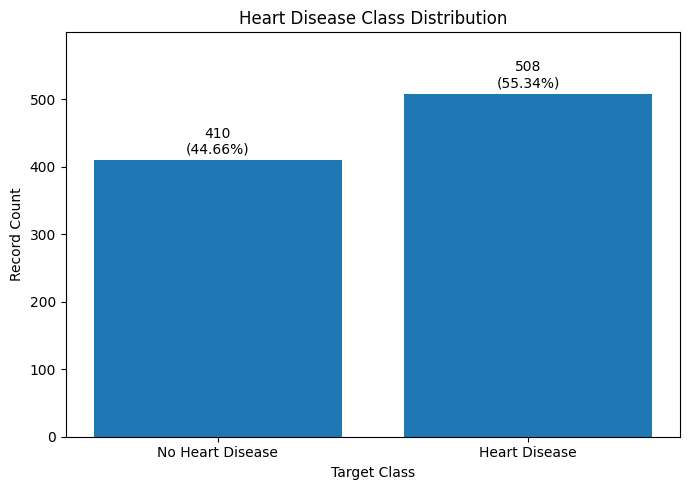

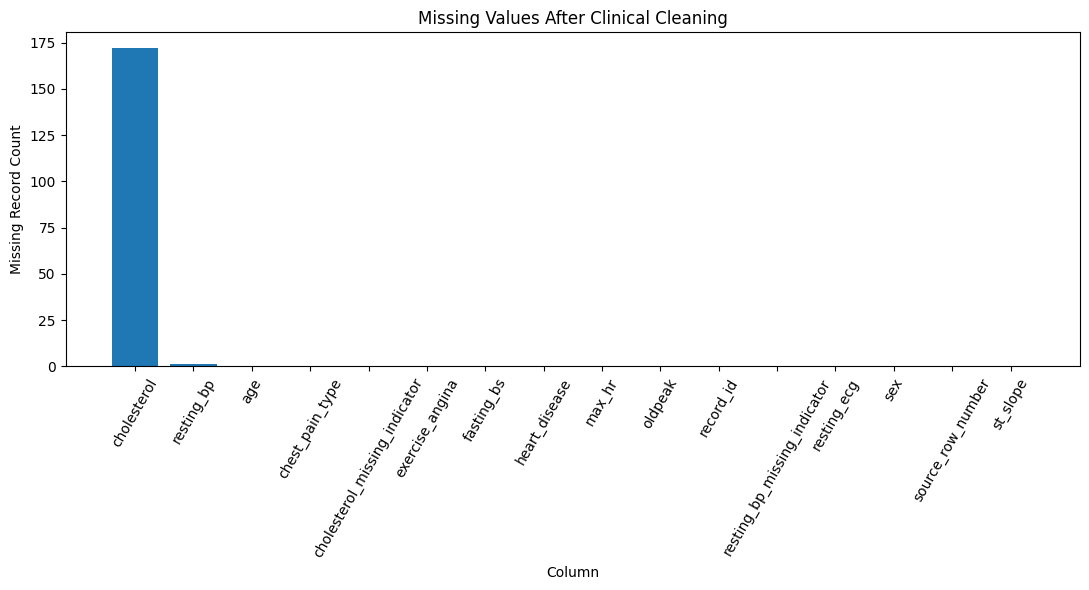

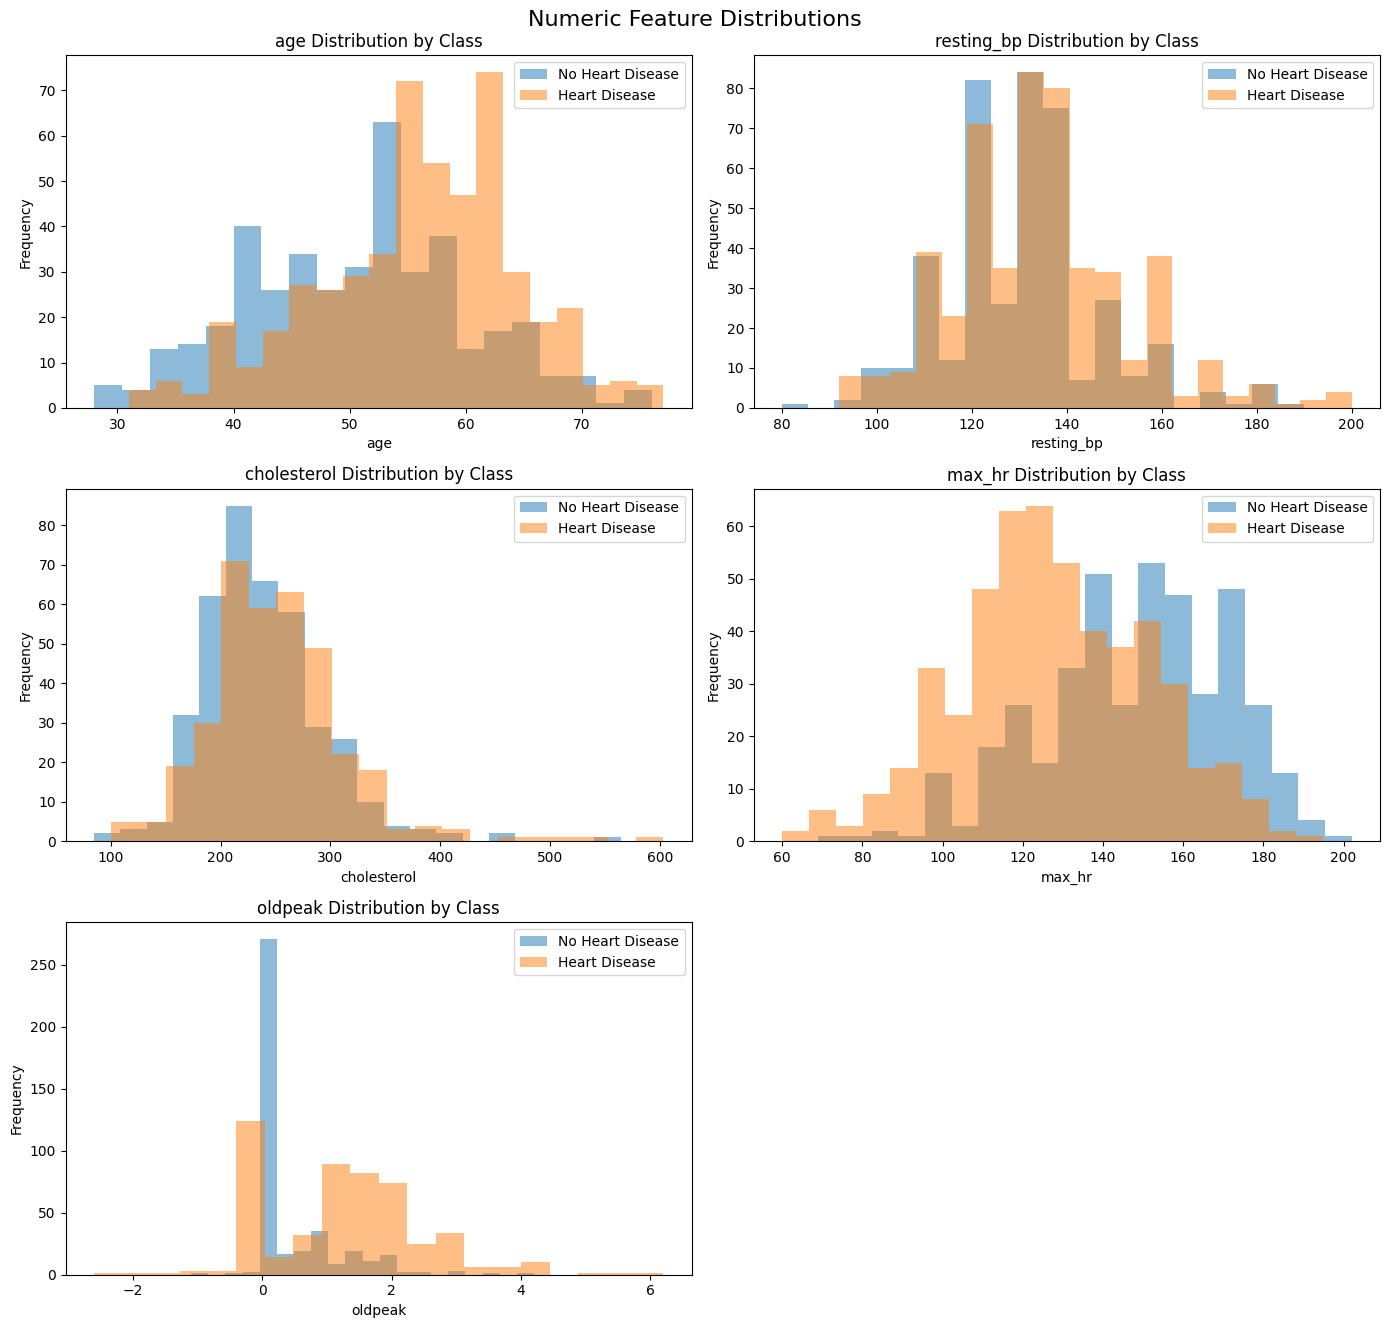

/tmp/ipykernel_2150/2339454202.py:521: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(
/tmp/ipykernel_2150/2339454202.py:521: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(
/tmp/ipykernel_2150/2339454202.py:521: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(
/tmp/ipykernel_2150/2339454202.py:521: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(
/tmp/ipykernel_2150/2339454202.py:521: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot()

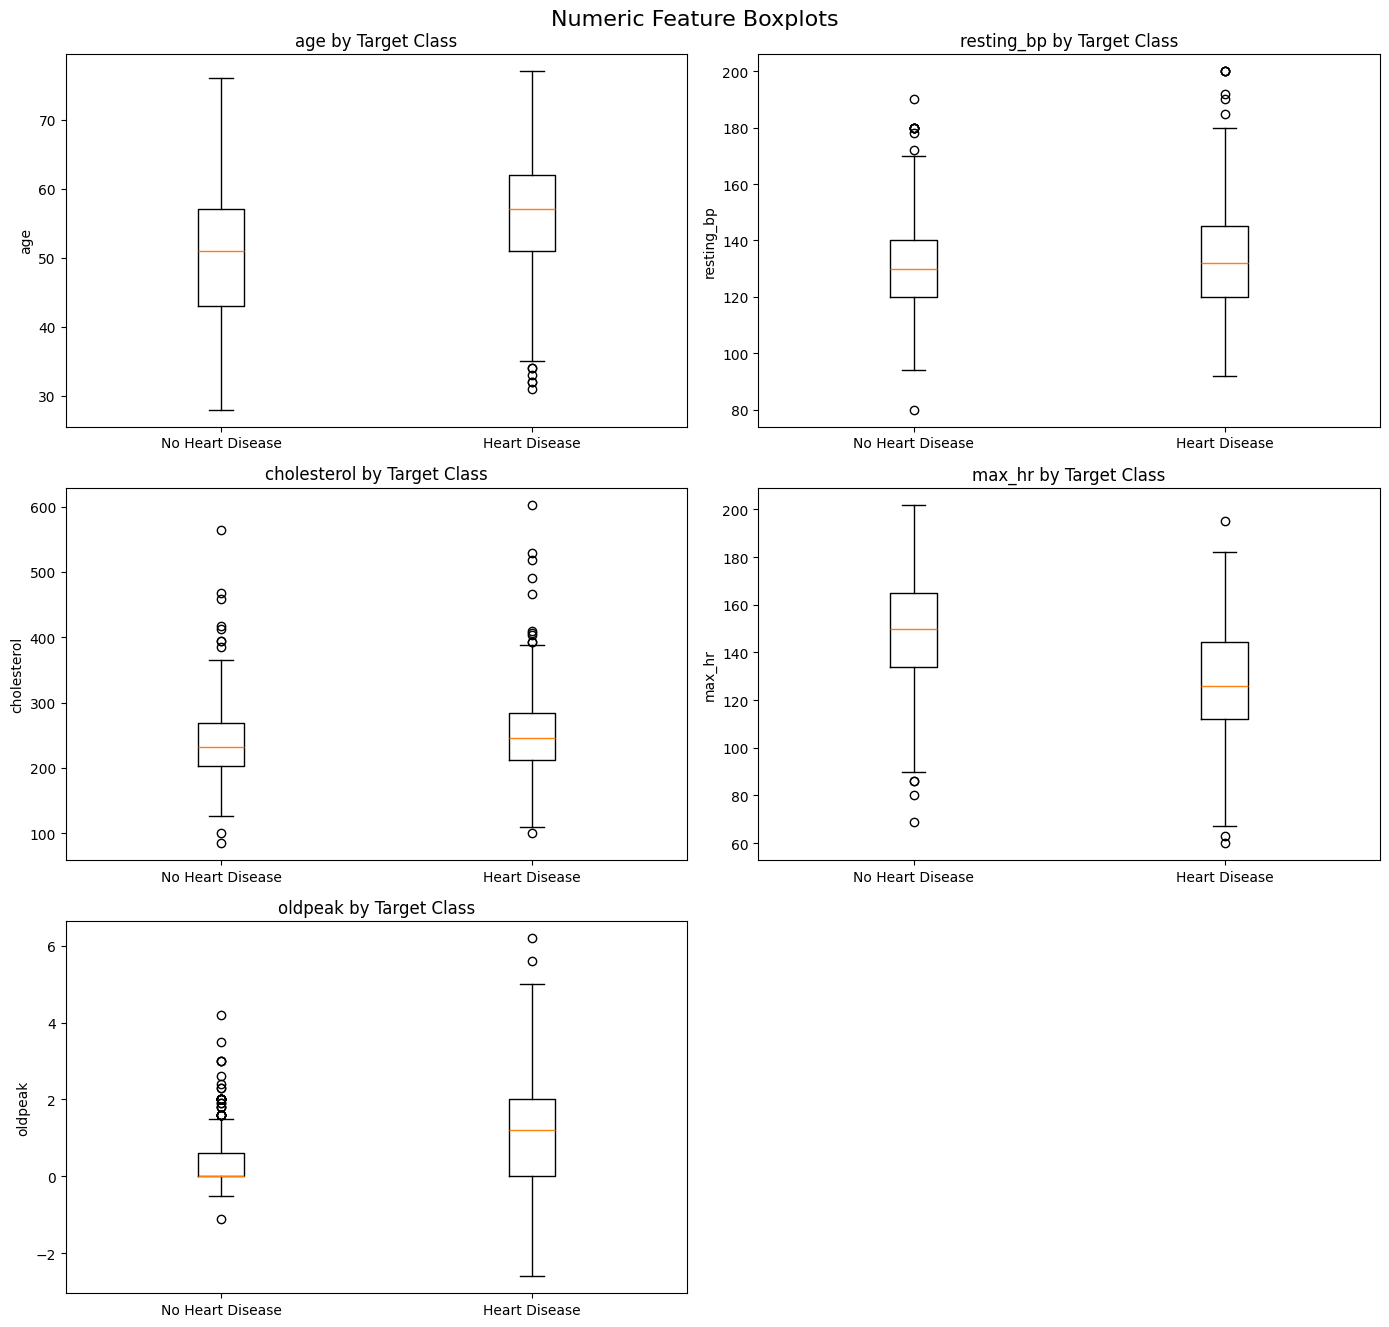

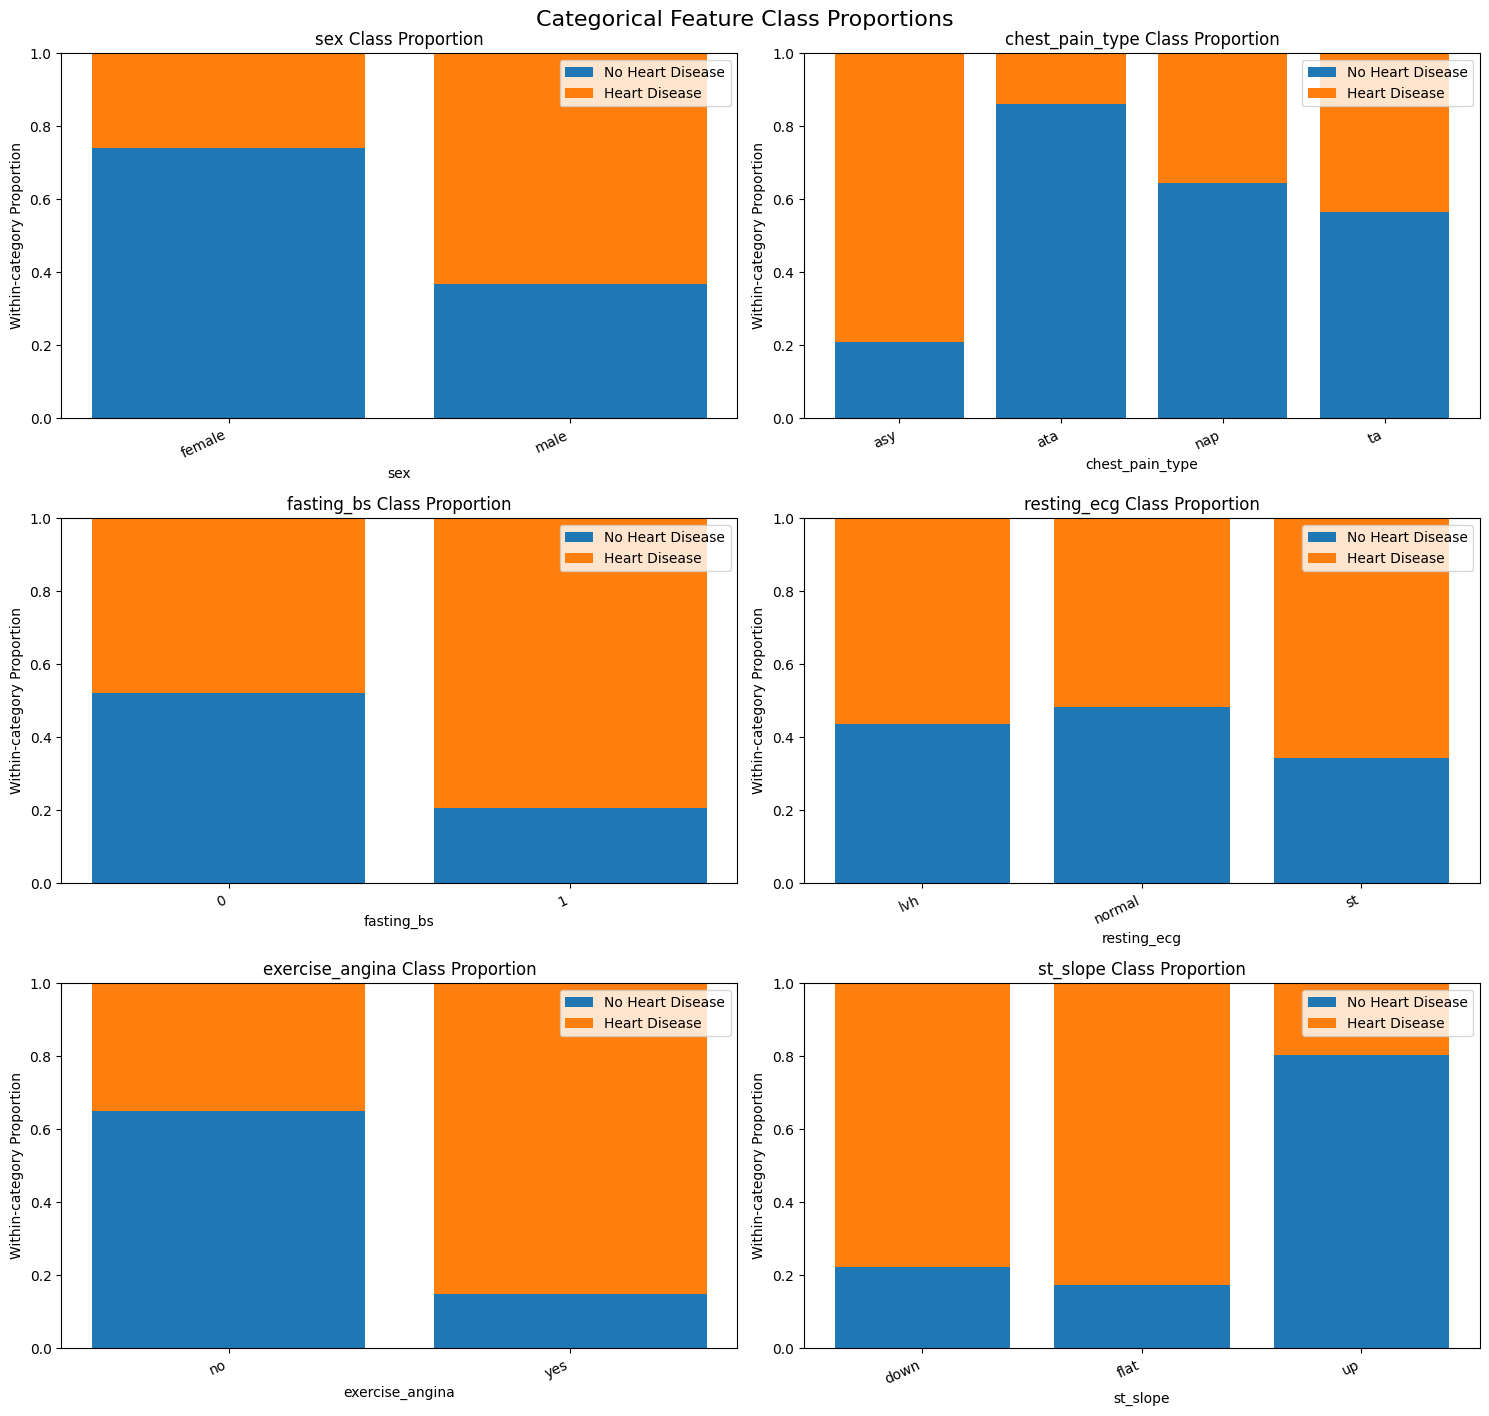

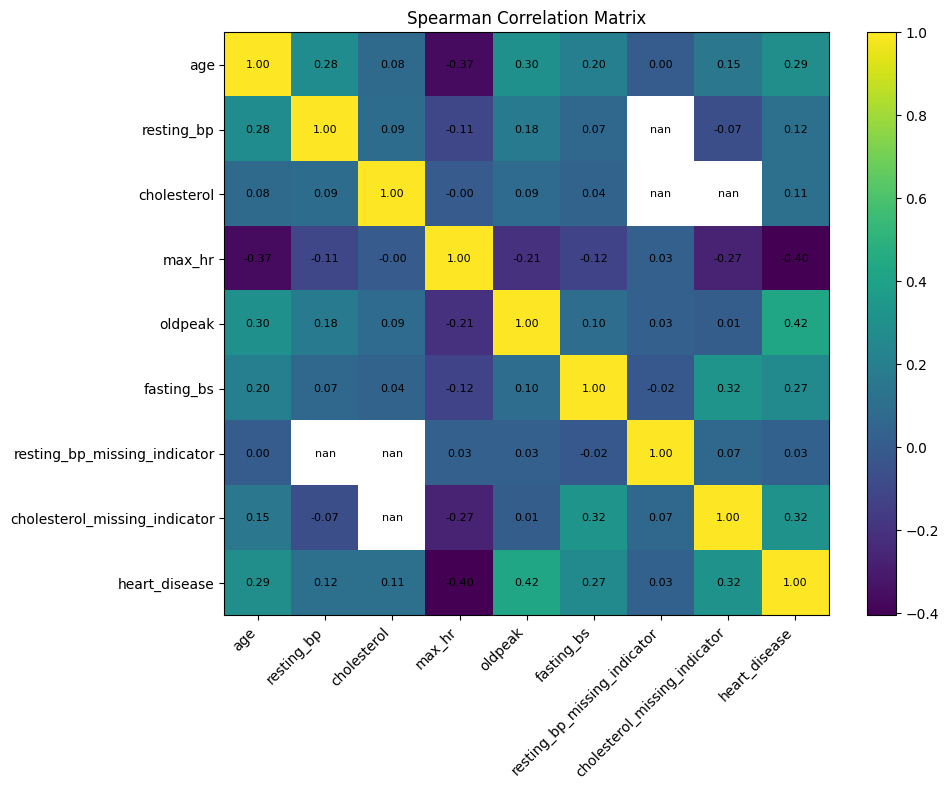

Class distribution:


,class_value,class_label,count,percentage
0,0,No Heart Disease,410,44.66
1,1,Heart Disease,508,55.34



Imbalance assessment:


,minority_count,majority_count,minority_to_majority_ratio,practical_threshold,distribution_status,resampling_required
0,410,508,0.8071,0.8,acceptable,False



Missing-value report:


...

,feature,category,count,percentage
0,sex,male,725,78.98
1,sex,female,193,21.02
2,chest_pain_type,asy,496,54.03
3,chest_pain_type,nap,203,22.11
4,chest_pain_type,ata,173,18.85
5,chest_pain_type,ta,46,5.01
6,fasting_bs,0,704,76.69
7,fasting_bs,1,214,23.31
8,resting_ecg,normal,552,60.13
9,resting_ecg,lvh,188,20.48



Target-wise numeric summary:


age                                     resting_bp  \
              count       mean median       std min max      count   
heart_disease                                                        
0               410  50.551220   51.0  9.444915  28  76        410   
1               508  55.899606   57.0  8.727056  31  77        507   

                                             ... max_hr                      \
                     mean median        std  ... median        std min  max   
heart_disease                                ...                              
0              130.180488  130.0  16.499585  ...  150.0  23.288067  69  202   
1              134.449704  132.0  18.928797  ...  126.0  23.386923  60  195   

              oldpeak                                       
                count      mean median       std  min  max  
heart_disease                                               
0                 410  0.408049    0.0  0.699709 -1.1  4.2  
1                 508  1.274213    1.2  1.151872 -2.6  6.2  

[2 rows x 30 columns]


Outlier report:


,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percentage
0,age,47.00,60.0,13.00,27.500,79.500,0,0.00
1,resting_bp,120.00,140.0,20.00,90.000,170.000,27,2.94
2,cholesterol,207.25,275.0,67.75,105.625,376.625,23,3.08
3,max_hr,120.00,156.0,36.00,66.000,210.000,2,0.22
4,oldpeak,0.00,1.5,1.50,-2.250,3.750,16,1.74


In [67]:
# ------------------------------------------------------------
# A. EDA configuration
# ------------------------------------------------------------

TARGET_COLUMN = "heart_disease"

CLASS_LABELS = {
    0: "No Heart Disease",
    1: "Heart Disease",
}

NUMERIC_EDA_COLUMNS = [
    "age",
    "resting_bp",
    "cholesterol",
    "max_hr",
    "oldpeak",
]

CATEGORICAL_EDA_COLUMNS = [
    "sex",
    "chest_pain_type",
    "fasting_bs",
    "resting_ecg",
    "exercise_angina",
    "st_slope",
]

MISSING_INDICATOR_COLUMNS = [
    "resting_bp_missing_indicator",
    "cholesterol_missing_indicator",
]


# ------------------------------------------------------------
# B. Class distribution and imbalance assessment
# ------------------------------------------------------------

observed_classes = set(
    cleaned_clinical_df[
        TARGET_COLUMN
    ]
    .dropna()
    .unique()
    .tolist()
)

if observed_classes != {0, 1}:
    raise ValueError(
        "Expected target classes {0, 1}, but found "
        f"{sorted(observed_classes)}."
    )

class_counts = (
    cleaned_clinical_df[
        TARGET_COLUMN
    ]
    .value_counts()
    .reindex(
        [0, 1],
        fill_value=0,
    )
)

class_distribution_df = pd.DataFrame(
    {
        "class_value": [0, 1],
        "class_label": [
            CLASS_LABELS[0],
            CLASS_LABELS[1],
        ],
        "count": [
            int(class_counts.loc[0]),
            int(class_counts.loc[1]),
        ],
    }
)

class_distribution_df[
    "percentage"
] = (
    class_distribution_df["count"]
    / len(cleaned_clinical_df)
    * 100
).round(2)

minority_count = int(class_counts.min())
majority_count = int(class_counts.max())

minority_majority_ratio = (
    minority_count / majority_count
)

PRACTICAL_IMBALANCE_THRESHOLD = 0.80

resampling_required = bool(
    minority_majority_ratio
    < PRACTICAL_IMBALANCE_THRESHOLD
)

imbalance_assessment_df = pd.DataFrame(
    [
        {
            "minority_count": minority_count,
            "majority_count": majority_count,
            "minority_to_majority_ratio": round(
                minority_majority_ratio,
                4,
            ),
            "practical_threshold": (
                PRACTICAL_IMBALANCE_THRESHOLD
            ),
            "distribution_status": (
                "meaningfully_imbalanced"
                if resampling_required
                else "acceptable"
            ),
            "resampling_required": (
                resampling_required
            ),
        }
    ]
)


# ------------------------------------------------------------
# C. Missing-value report
# ------------------------------------------------------------

missing_report_df = pd.DataFrame(
    {
        "column": cleaned_clinical_df.columns,
        "missing_count": (
            cleaned_clinical_df
            .isna()
            .sum()
            .values
        ),
    }
)

missing_report_df[
    "missing_percentage"
] = (
    missing_report_df["missing_count"]
    / len(cleaned_clinical_df)
    * 100
).round(2)

missing_report_df = (
    missing_report_df
    .sort_values(
        by=[
            "missing_count",
            "column",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# D. Numeric descriptive statistics
# ------------------------------------------------------------

numeric_summary_df = (
    cleaned_clinical_df[
        NUMERIC_EDA_COLUMNS
    ]
    .describe()
    .transpose()
    .reset_index()
    .rename(
        columns={
            "index": "feature",
        }
    )
)


# ------------------------------------------------------------
# E. Categorical frequencies
# ------------------------------------------------------------

categorical_frequency_records = []

for feature in (
    CATEGORICAL_EDA_COLUMNS
    + MISSING_INDICATOR_COLUMNS
):
    category_counts = (
        cleaned_clinical_df[feature]
        .astype("string")
        .fillna("<missing>")
        .value_counts(dropna=False)
    )

    for category_value, count in category_counts.items():
        categorical_frequency_records.append(
            {
                "feature": feature,
                "category": str(category_value),
                "count": int(count),
                "percentage": round(
                    int(count)
                    / len(cleaned_clinical_df)
                    * 100,
                    2,
                ),
            }
        )

categorical_frequency_df = pd.DataFrame(
    categorical_frequency_records
)


# ------------------------------------------------------------
# F. Target-wise numeric statistics
# ------------------------------------------------------------

target_numeric_summary_df = (
    cleaned_clinical_df
    .groupby(
        TARGET_COLUMN,
        observed=True,
    )[
        NUMERIC_EDA_COLUMNS
    ]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max",
        ]
    )
)


# ------------------------------------------------------------
# G. IQR-based outlier report
# ------------------------------------------------------------

outlier_records = []

for feature in NUMERIC_EDA_COLUMNS:
    feature_values = (
        cleaned_clinical_df[feature]
        .dropna()
    )

    q1 = float(
        feature_values.quantile(0.25)
    )

    q3 = float(
        feature_values.quantile(0.75)
    )

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (
        feature_values.lt(lower_bound)
        | feature_values.gt(upper_bound)
    )

    outlier_count = int(
        outlier_mask.sum()
    )

    outlier_records.append(
        {
            "feature": feature,
            "q1": round(q1, 4),
            "q3": round(q3, 4),
            "iqr": round(iqr, 4),
            "lower_bound": round(
                lower_bound,
                4,
            ),
            "upper_bound": round(
                upper_bound,
                4,
            ),
            "outlier_count": outlier_count,
            "outlier_percentage": round(
                outlier_count
                / len(feature_values)
                * 100,
                2,
            ),
        }
    )

outlier_report_df = pd.DataFrame(
    outlier_records
)


# ------------------------------------------------------------
# H. Class-distribution plot
# ------------------------------------------------------------

figure, axis = plt.subplots(
    figsize=(7, 5)
)

bars = axis.bar(
    class_distribution_df["class_label"],
    class_distribution_df["count"],
)

axis.set_title(
    "Heart Disease Class Distribution"
)

axis.set_xlabel("Target Class")
axis.set_ylabel("Record Count")

axis.set_ylim(
    0,
    class_distribution_df["count"].max()
    * 1.18,
)

for bar, percentage in zip(
    bars,
    class_distribution_df["percentage"],
):
    axis.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height() + 5,
        (
            f"{int(bar.get_height())}\n"
            f"({percentage:.2f}%)"
        ),
        ha="center",
        va="bottom",
    )

plt.tight_layout()

figure.savefig(
    EDA_DIR / "class_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


# ------------------------------------------------------------
# I. Missing-value plot
# ------------------------------------------------------------

figure, axis = plt.subplots(
    figsize=(11, 6)
)

axis.bar(
    missing_report_df["column"],
    missing_report_df["missing_count"],
)

axis.set_title(
    "Missing Values After Clinical Cleaning"
)

axis.set_xlabel("Column")
axis.set_ylabel("Missing Record Count")

axis.tick_params(
    axis="x",
    rotation=60,
)

plt.tight_layout()

figure.savefig(
    EDA_DIR / "missing_value_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


# ------------------------------------------------------------
# J. Numeric distributions by class
# ------------------------------------------------------------

plot_columns = 2

plot_rows = math.ceil(
    len(NUMERIC_EDA_COLUMNS)
    / plot_columns
)

figure, axes = plt.subplots(
    plot_rows,
    plot_columns,
    figsize=(
        14,
        4.5 * plot_rows,
    ),
)

axes = np.asarray(
    axes
).reshape(-1)

for axis, feature in zip(
    axes,
    NUMERIC_EDA_COLUMNS,
):
    for class_value in [0, 1]:
        values = (
            cleaned_clinical_df.loc[
                cleaned_clinical_df[
                    TARGET_COLUMN
                ].eq(class_value),
                feature,
            ]
            .dropna()
        )

        axis.hist(
            values,
            bins=20,
            alpha=0.5,
            label=CLASS_LABELS[
                class_value
            ],
        )

    axis.set_title(
        f"{feature} Distribution by Class"
    )

    axis.set_xlabel(feature)
    axis.set_ylabel("Frequency")
    axis.legend()

for unused_axis in axes[
    len(NUMERIC_EDA_COLUMNS):
]:
    figure.delaxes(unused_axis)

figure.suptitle(
    "Numeric Feature Distributions",
    fontsize=16,
)

plt.tight_layout()

figure.savefig(
    EDA_DIR
    / "numeric_distributions_by_class.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


# ------------------------------------------------------------
# K. Numeric boxplots by class
# ------------------------------------------------------------

figure, axes = plt.subplots(
    plot_rows,
    plot_columns,
    figsize=(
        14,
        4.5 * plot_rows,
    ),
)

axes = np.asarray(
    axes
).reshape(-1)

for axis, feature in zip(
    axes,
    NUMERIC_EDA_COLUMNS,
):
    class_zero_values = (
        cleaned_clinical_df.loc[
            cleaned_clinical_df[
                TARGET_COLUMN
            ].eq(0),
            feature,
        ]
        .dropna()
    )

    class_one_values = (
        cleaned_clinical_df.loc[
            cleaned_clinical_df[
                TARGET_COLUMN
            ].eq(1),
            feature,
        ]
        .dropna()
    )

    axis.boxplot(
        [
            class_zero_values,
            class_one_values,
        ],
        labels=[
            CLASS_LABELS[0],
            CLASS_LABELS[1],
        ],
    )

    axis.set_title(
        f"{feature} by Target Class"
    )

    axis.set_ylabel(feature)

for unused_axis in axes[
    len(NUMERIC_EDA_COLUMNS):
]:
    figure.delaxes(unused_axis)

figure.suptitle(
    "Numeric Feature Boxplots",
    fontsize=16,
)

plt.tight_layout()

figure.savefig(
    EDA_DIR
    / "numeric_boxplots_by_class.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


# ------------------------------------------------------------
# L. Categorical class proportions
# ------------------------------------------------------------

categorical_plot_rows = math.ceil(
    len(CATEGORICAL_EDA_COLUMNS)
    / plot_columns
)

figure, axes = plt.subplots(
    categorical_plot_rows,
    plot_columns,
    figsize=(
        15,
        4.8 * categorical_plot_rows,
    ),
)

axes = np.asarray(
    axes
).reshape(-1)

for axis, feature in zip(
    axes,
    CATEGORICAL_EDA_COLUMNS,
):
    proportion_table = pd.crosstab(
        cleaned_clinical_df[feature],
        cleaned_clinical_df[
            TARGET_COLUMN
        ],
        normalize="index",
    ).reindex(
        columns=[0, 1],
        fill_value=0,
    )

    x_positions = np.arange(
        len(proportion_table.index)
    )

    bottom_values = np.zeros(
        len(proportion_table.index)
    )

    for class_value in [0, 1]:
        class_proportions = (
            proportion_table[class_value]
            .to_numpy()
        )

        axis.bar(
            x_positions,
            class_proportions,
            bottom=bottom_values,
            label=CLASS_LABELS[
                class_value
            ],
        )

        bottom_values = (
            bottom_values
            + class_proportions
        )

    axis.set_xticks(x_positions)

    axis.set_xticklabels(
        proportion_table
        .index
        .astype(str),
        rotation=25,
        ha="right",
    )

    axis.set_ylim(0, 1)

    axis.set_title(
        f"{feature} Class Proportion"
    )

    axis.set_xlabel(feature)

    axis.set_ylabel(
        "Within-category Proportion"
    )

    axis.legend()

for unused_axis in axes[
    len(CATEGORICAL_EDA_COLUMNS):
]:
    figure.delaxes(unused_axis)

figure.suptitle(
    "Categorical Feature Class Proportions",
    fontsize=16,
)

plt.tight_layout()

figure.savefig(
    EDA_DIR
    / "categorical_class_proportions.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


# ------------------------------------------------------------
# M. Spearman correlation matrix
# ------------------------------------------------------------

CORRELATION_COLUMNS = (
    NUMERIC_EDA_COLUMNS
    + [
        "fasting_bs",
        "resting_bp_missing_indicator",
        "cholesterol_missing_indicator",
        TARGET_COLUMN,
    ]
)

correlation_df = (
    cleaned_clinical_df[
        CORRELATION_COLUMNS
    ]
    .corr(method="spearman")
)

figure, axis = plt.subplots(
    figsize=(10, 8)
)

heatmap = axis.imshow(
    correlation_df.to_numpy(),
    aspect="auto",
)

axis.set_xticks(
    range(
        len(CORRELATION_COLUMNS)
    )
)

axis.set_yticks(
    range(
        len(CORRELATION_COLUMNS)
    )
)

axis.set_xticklabels(
    CORRELATION_COLUMNS,
    rotation=45,
    ha="right",
)

axis.set_yticklabels(
    CORRELATION_COLUMNS
)

for row_index in range(
    len(CORRELATION_COLUMNS)
):
    for column_index in range(
        len(CORRELATION_COLUMNS)
    ):
        correlation_value = (
            correlation_df.iloc[
                row_index,
                column_index,
            ]
        )

        axis.text(
            column_index,
            row_index,
            f"{correlation_value:.2f}",
            ha="center",
            va="center",
            fontsize=8,
        )

figure.colorbar(
    heatmap,
    ax=axis,
)

axis.set_title(
    "Spearman Correlation Matrix"
)

plt.tight_layout()

figure.savefig(
    EDA_DIR
    / "spearman_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


# ------------------------------------------------------------
# N. Save EDA tables
# ------------------------------------------------------------

class_distribution_df.to_csv(
    EDA_DIR / "class_distribution.csv",
    index=False,
)

imbalance_assessment_df.to_csv(
    EDA_DIR / "imbalance_assessment.csv",
    index=False,
)

missing_report_df.to_csv(
    EDA_DIR / "missing_report.csv",
    index=False,
)

numeric_summary_df.to_csv(
    EDA_DIR / "numeric_summary.csv",
    index=False,
)

categorical_frequency_df.to_csv(
    EDA_DIR / "categorical_frequency.csv",
    index=False,
)

target_numeric_summary_df.to_csv(
    EDA_DIR / "target_numeric_summary.csv"
)

outlier_report_df.to_csv(
    EDA_DIR / "outlier_report.csv",
    index=False,
)

correlation_df.to_csv(
    EDA_DIR / "spearman_correlation.csv"
)


print("Class distribution:")
display(
    class_distribution_df
)

print("\nImbalance assessment:")
display(
    imbalance_assessment_df
)

print("\nMissing-value report:")
display(
    missing_report_df
)

print("\nNumeric summary:")
display(
    numeric_summary_df
)

print("\nCategorical frequency report:")
display(
    categorical_frequency_df
)

print("\nTarget-wise numeric summary:")
display(
    target_numeric_summary_df
)

print("\nOutlier report:")
display(
    outlier_report_df
)

## Step 5: Stratified Train–Validation–Test Split

In [68]:
from sklearn.model_selection import train_test_split


# ------------------------------------------------------------
# A. Split configuration
# ------------------------------------------------------------

TRAIN_SIZE = 0.70
VALIDATION_SIZE = 0.15
TEST_SIZE = 0.15
RANDOM_STATE = 42

if not np.isclose(
    TRAIN_SIZE + VALIDATION_SIZE + TEST_SIZE,
    1.0,
):
    raise ValueError(
        "Train, validation, and test sizes must add up to 1.0."
    )


# ------------------------------------------------------------
# B. Train and temporary split
# ------------------------------------------------------------

train_df, temporary_df = train_test_split(
    cleaned_clinical_df,
    test_size=VALIDATION_SIZE + TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=cleaned_clinical_df[TARGET_COLUMN],
)


# ------------------------------------------------------------
# C. Validation and test split
# ------------------------------------------------------------

test_fraction_of_temporary = (
    TEST_SIZE
    / (VALIDATION_SIZE + TEST_SIZE)
)

validation_df, test_df = train_test_split(
    temporary_df,
    test_size=test_fraction_of_temporary,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=temporary_df[TARGET_COLUMN],
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


# ------------------------------------------------------------
# D. Verify split integrity
# ------------------------------------------------------------

total_split_records = (
    len(train_df)
    + len(validation_df)
    + len(test_df)
)

if total_split_records != len(cleaned_clinical_df):
    raise RuntimeError(
        "Split record count does not match the cleaned dataset."
    )

train_ids = set(train_df["record_id"])
validation_ids = set(validation_df["record_id"])
test_ids = set(test_df["record_id"])

if not train_ids.isdisjoint(validation_ids):
    raise RuntimeError(
        "Train and validation sets overlap."
    )

if not train_ids.isdisjoint(test_ids):
    raise RuntimeError(
        "Train and test sets overlap."
    )

if not validation_ids.isdisjoint(test_ids):
    raise RuntimeError(
        "Validation and test sets overlap."
    )


# ------------------------------------------------------------
# E. Build split reports
# ------------------------------------------------------------

def build_split_distribution(dataframe, split_name):
    split_class_counts = (
        dataframe[TARGET_COLUMN]
        .value_counts()
        .reindex(
            [0, 1],
            fill_value=0,
        )
    )

    return pd.DataFrame(
        {
            "split": [
                split_name,
                split_name,
            ],
            "class_value": [0, 1],
            "class_label": [
                CLASS_LABELS[0],
                CLASS_LABELS[1],
            ],
            "count": [
                int(split_class_counts.loc[0]),
                int(split_class_counts.loc[1]),
            ],
            "percentage": [
                round(
                    split_class_counts.loc[0]
                    / len(dataframe)
                    * 100,
                    2,
                ),
                round(
                    split_class_counts.loc[1]
                    / len(dataframe)
                    * 100,
                    2,
                ),
            ],
        }
    )


split_class_distribution_df = pd.concat(
    [
        build_split_distribution(
            train_df,
            "train",
        ),
        build_split_distribution(
            validation_df,
            "validation",
        ),
        build_split_distribution(
            test_df,
            "test",
        ),
    ],
    ignore_index=True,
)

split_summary_df = pd.DataFrame(
    [
        {
            "split": "train",
            "records": len(train_df),
            "percentage": round(
                len(train_df)
                / len(cleaned_clinical_df)
                * 100,
                2,
            ),
        },
        {
            "split": "validation",
            "records": len(validation_df),
            "percentage": round(
                len(validation_df)
                / len(cleaned_clinical_df)
                * 100,
                2,
            ),
        },
        {
            "split": "test",
            "records": len(test_df),
            "percentage": round(
                len(test_df)
                / len(cleaned_clinical_df)
                * 100,
                2,
            ),
        },
    ]
)


# ------------------------------------------------------------
# F. Save raw splits
# ------------------------------------------------------------

train_df.to_csv(
    OUTPUT_DIR / "train_raw.csv",
    index=False,
)

validation_df.to_csv(
    OUTPUT_DIR / "validation_raw.csv",
    index=False,
)

test_df.to_csv(
    OUTPUT_DIR / "test_raw.csv",
    index=False,
)

split_class_distribution_df.to_csv(
    OUTPUT_DIR / "split_class_distribution.csv",
    index=False,
)

split_summary_df.to_csv(
    OUTPUT_DIR / "split_summary.csv",
    index=False,
)


print("Stratified split completed.")

display(split_summary_df)
display(split_class_distribution_df)

Stratified split completed.


,split,records,percentage
0,train,642,69.93
1,validation,138,15.03
2,test,138,15.03


,split,class_value,class_label,count,percentage
0,train,0,No Heart Disease,287,44.70
1,train,1,Heart Disease,355,55.30
2,validation,0,No Heart Disease,61,44.20
3,validation,1,Heart Disease,77,55.80
4,test,0,No Heart Disease,62,44.93
5,test,1,Heart Disease,76,55.07


## Step 6:  Resampling Decision

Only the training split is assessed. Validation and test sets are never resampled.  
For this dataset, the training minority-to-majority ratio is approximately `0.81`, so no resampling is applied.

In [69]:
# ------------------------------------------------------------
# A. Assess training class distribution
# ------------------------------------------------------------

training_class_counts = (
    train_df[TARGET_COLUMN]
    .value_counts()
    .reindex(
        [0, 1],
        fill_value=0,
    )
)

training_minority_count = int(
    training_class_counts.min()
)

training_majority_count = int(
    training_class_counts.max()
)

training_minority_majority_ratio = (
    training_minority_count
    / training_majority_count
)


# ------------------------------------------------------------
# B. Make the resampling decision
# ------------------------------------------------------------

resampling_applied = False

if (
    training_minority_majority_ratio
    >= PRACTICAL_IMBALANCE_THRESHOLD
):
    resampling_decision = (
        "No resampling required because the "
        "training class distribution is acceptable."
    )
else:
    resampling_decision = (
        "No resampling applied because the class "
        "distribution will be handled during model training."
    )

model_train_df = train_df.copy()


# ------------------------------------------------------------
# C. Save decision report
# ------------------------------------------------------------

resampling_decision_df = pd.DataFrame(
    [
        {
            "train_class_0_count": int(
                training_class_counts.loc[0]
            ),
            "train_class_1_count": int(
                training_class_counts.loc[1]
            ),
            "minority_count": (
                training_minority_count
            ),
            "majority_count": (
                training_majority_count
            ),
            "minority_to_majority_ratio": round(
                training_minority_majority_ratio,
                4,
            ),
            "practical_threshold": (
                PRACTICAL_IMBALANCE_THRESHOLD
            ),
            "resampling_applied": (
                resampling_applied
            ),
            "decision": (
                resampling_decision
            ),
        }
    ]
)

resampling_decision_df.to_csv(
    OUTPUT_DIR / "resampling_decision.csv",
    index=False,
)


print(
    "Training class 0 count : "
    f"{int(training_class_counts.loc[0])}"
)

print(
    "Training class 1 count : "
    f"{int(training_class_counts.loc[1])}"
)

print(
    "Minority/Majority ratio: "
    f"{training_minority_majority_ratio:.4f}"
)

print(
    f"Resampling applied     : {resampling_applied}"
)

print(
    f"Decision               : {resampling_decision}"
)

display(
    resampling_decision_df
)

Training class 0 count : 287
Training class 1 count : 355
Minority/Majority ratio: 0.8085
Resampling applied     : False
Decision               : No resampling required because the training class distribution is acceptable.


,train_class_0_count,train_class_1_count,minority_count,majority_count,minority_to_majority_ratio,practical_threshold,resampling_applied,decision
0,287,355,287,355,0.8085,0.8,False,No resampling required because the training cl...


## Step 7: Training-Only Imputation, Encoding, and Scaling

The preprocessor is fitted **only on the training features**. The fitted transformer is then applied to validation and test features.

In [70]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# ------------------------------------------------------------
# A. Define model features
# ------------------------------------------------------------

NUMERIC_MODEL_FEATURES = [
    "age",
    "resting_bp",
    "cholesterol",
    "max_hr",
    "oldpeak",
]

BINARY_MODEL_FEATURES = [
    "fasting_bs",
    "resting_bp_missing_indicator",
    "cholesterol_missing_indicator",
]

CATEGORICAL_MODEL_FEATURES = [
    "sex",
    "chest_pain_type",
    "resting_ecg",
    "exercise_angina",
    "st_slope",
]

MODEL_FEATURES = (
    NUMERIC_MODEL_FEATURES
    + BINARY_MODEL_FEATURES
    + CATEGORICAL_MODEL_FEATURES
)


# ------------------------------------------------------------
# B. Separate features and target
# ------------------------------------------------------------

X_train = model_train_df[
    MODEL_FEATURES
].copy()

y_train = (
    model_train_df[TARGET_COLUMN]
    .astype("int8")
    .copy()
)

X_validation = validation_df[
    MODEL_FEATURES
].copy()

y_validation = (
    validation_df[TARGET_COLUMN]
    .astype("int8")
    .copy()
)

X_test = test_df[
    MODEL_FEATURES
].copy()

y_test = (
    test_df[TARGET_COLUMN]
    .astype("int8")
    .copy()
)


# Convert categorical features to object type
# for reliable sklearn preprocessing
for dataframe in [
    X_train,
    X_validation,
    X_test,
]:
    dataframe[
        CATEGORICAL_MODEL_FEATURES
    ] = dataframe[
        CATEGORICAL_MODEL_FEATURES
    ].astype("object")


# ------------------------------------------------------------
# C. Build preprocessing pipelines
# ------------------------------------------------------------

numeric_pipeline = Pipeline(
    steps=[
        (
            "median_imputer",
            SimpleImputer(
                strategy="median"
            ),
        ),
        (
            "standard_scaler",
            StandardScaler(),
        ),
    ]
)

binary_pipeline = Pipeline(
    steps=[
        (
            "most_frequent_imputer",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "most_frequent_imputer",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
        (
            "one_hot_encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            NUMERIC_MODEL_FEATURES,
        ),
        (
            "binary",
            binary_pipeline,
            BINARY_MODEL_FEATURES,
        ),
        (
            "categorical",
            categorical_pipeline,
            CATEGORICAL_MODEL_FEATURES,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)


# ------------------------------------------------------------
# D. Fit on training data only
# ------------------------------------------------------------

X_train_processed_array = (
    preprocessor.fit_transform(
        X_train
    )
)

X_validation_processed_array = (
    preprocessor.transform(
        X_validation
    )
)

X_test_processed_array = (
    preprocessor.transform(
        X_test
    )
)


# ------------------------------------------------------------
# E. Convert to model-ready DataFrames
# ------------------------------------------------------------

processed_feature_names = (
    preprocessor
    .get_feature_names_out()
    .tolist()
)

X_train_processed = pd.DataFrame(
    X_train_processed_array,
    columns=processed_feature_names,
)

X_validation_processed = pd.DataFrame(
    X_validation_processed_array,
    columns=processed_feature_names,
)

X_test_processed = pd.DataFrame(
    X_test_processed_array,
    columns=processed_feature_names,
)


train_model_ready_df = (
    X_train_processed.copy()
)

train_model_ready_df[
    TARGET_COLUMN
] = y_train.to_numpy()


validation_model_ready_df = (
    X_validation_processed.copy()
)

validation_model_ready_df[
    TARGET_COLUMN
] = y_validation.to_numpy()


test_model_ready_df = (
    X_test_processed.copy()
)

test_model_ready_df[
    TARGET_COLUMN
] = y_test.to_numpy()


# ------------------------------------------------------------
# F. Verify model-ready outputs
# ------------------------------------------------------------

processed_datasets = {
    "train": train_model_ready_df,
    "validation": validation_model_ready_df,
    "test": test_model_ready_df,
}

for dataset_name, dataframe in processed_datasets.items():
    remaining_missing_count = int(
        dataframe.isna().sum().sum()
    )

    if remaining_missing_count > 0:
        raise RuntimeError(
            f"{remaining_missing_count} missing values "
            f"remain in the processed {dataset_name} set."
        )

if len(train_model_ready_df) != len(model_train_df):
    raise RuntimeError(
        "Processed training row count changed."
    )

if len(validation_model_ready_df) != len(validation_df):
    raise RuntimeError(
        "Processed validation row count changed."
    )

if len(test_model_ready_df) != len(test_df):
    raise RuntimeError(
        "Processed test row count changed."
    )


# ------------------------------------------------------------
# G. Save outputs
# ------------------------------------------------------------

train_model_ready_df.to_csv(
    OUTPUT_DIR / "train_model_ready.csv",
    index=False,
)

validation_model_ready_df.to_csv(
    OUTPUT_DIR / "validation_model_ready.csv",
    index=False,
)

test_model_ready_df.to_csv(
    OUTPUT_DIR / "test_model_ready.csv",
    index=False,
)

pd.DataFrame(
    {
        "feature_name": processed_feature_names
    }
).to_csv(
    OUTPUT_DIR / "model_feature_names.csv",
    index=False,
)

joblib.dump(
    preprocessor,
    OUTPUT_DIR
    / "training_fitted_preprocessor.joblib",
)


preprocessing_summary_df = pd.DataFrame(
    [
        {
            "train_rows": len(
                train_model_ready_df
            ),
            "validation_rows": len(
                validation_model_ready_df
            ),
            "test_rows": len(
                test_model_ready_df
            ),
            "original_model_feature_count": len(
                MODEL_FEATURES
            ),
            "processed_feature_count": len(
                processed_feature_names
            ),
            "numeric_imputation": (
                "median fitted on training only"
            ),
            "categorical_imputation": (
                "most frequent fitted on training only"
            ),
            "categorical_encoding": (
                "one-hot encoding fitted on training only"
            ),
            "numeric_scaling": (
                "standard scaling fitted on training only"
            ),
            "resampling_applied": resampling_applied,
        }
    ]
)

preprocessing_summary_df.to_csv(
    OUTPUT_DIR / "preprocessing_summary.csv",
    index=False,
)


print("Training-only preprocessing completed.")
print(f"Training rows          : {len(train_model_ready_df):,}")
print(f"Validation rows        : {len(validation_model_ready_df):,}")
print(f"Test rows              : {len(test_model_ready_df):,}")
print(f"Input feature count    : {len(MODEL_FEATURES)}")
print(f"Processed feature count: {len(processed_feature_names)}")

print("\nProcessed features:")
print(processed_feature_names)

print("\nPreprocessing summary:")
display(
    preprocessing_summary_df
)

print("\nModel-ready training preview:")
display(
    train_model_ready_df.head()
)

Training-only preprocessing completed.
Training rows          : 642
Validation rows        : 138
Test rows              : 138
Input feature count    : 13
Processed feature count: 22

Processed features:
['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak', 'fasting_bs', 'resting_bp_missing_indicator', 'cholesterol_missing_indicator', 'sex_female', 'sex_male', 'chest_pain_type_asy', 'chest_pain_type_ata', 'chest_pain_type_nap', 'chest_pain_type_ta', 'resting_ecg_lvh', 'resting_ecg_normal', 'resting_ecg_st', 'exercise_angina_no', 'exercise_angina_yes', 'st_slope_down', 'st_slope_flat', 'st_slope_up']

Preprocessing summary:


,train_rows,validation_rows,test_rows,original_model_feature_count,processed_feature_count,numeric_imputation,categorical_imputation,categorical_encoding,numeric_scaling,resampling_applied
0,642,138,138,13,22,median fitted on training only,most frequent fitted on training only,one-hot encoding fitted on training only,standard scaling fitted on training only,False



Model-ready training preview:


,age,resting_bp,cholesterol,max_hr,oldpeak,fasting_bs,resting_bp_missing_indicator,cholesterol_missing_indicator,sex_female,sex_male,...,chest_pain_type_ta,resting_ecg_lvh,resting_ecg_normal,resting_ecg_st,exercise_angina_no,exercise_angina_yes,st_slope_down,st_slope_flat,st_slope_up,heart_disease
0,0.856064,-0.672618,-0.117719,-0.082372,-1.563271,1.0,0.0,1.0,0.0,1.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1
1,0.331343,0.435467,-0.117719,-0.629164,1.037503,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1
2,0.331343,0.989510,0.202517,-1.722749,1.966351,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1
3,1.905508,1.543553,-0.117719,-0.863504,0.665964,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
4,0.226399,2.097596,-0.117719,-0.511994,1.501927,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1


# STEP 8: Primary Hospital Development Dataset


In [71]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


# Primary hospital development dataset
development_df = model_train_df.copy()

print("Development Dataset Shape:")
print(development_df.shape)

print("\nColumns:")
print(development_df.columns.tolist())


# Target column
TARGET_COLUMN = "heart_disease"

# Features
X_development = development_df.drop(
    columns=[TARGET_COLUMN]
).copy()

# Target
y_development = development_df[
    TARGET_COLUMN
].astype(int)

print("X shape:", X_development.shape)
print("y shape:", y_development.shape)

Development Dataset Shape:
(642, 16)

Columns:
['record_id', 'source_row_number', 'age', 'sex', 'chest_pain_type', 'resting_bp', 'cholesterol', 'fasting_bs', 'resting_ecg', 'max_hr', 'exercise_angina', 'oldpeak', 'st_slope', 'heart_disease', 'resting_bp_missing_indicator', 'cholesterol_missing_indicator']
X shape: (642, 15)
y shape: (642,)


# STEP 9: Numerical Leakage-Free Preprocessing

In [72]:
# ============================================================
# NUMERICAL FEATURES
# ============================================================

NUMERICAL_FEATURES = [
    "age",
    "resting_bp",
    "cholesterol",
    "max_hr",
    "oldpeak"
]

print("Numerical Features:")
for col in NUMERICAL_FEATURES:
    print("- ", col)


# ============================================================
# NUMERICAL PREPROCESSING
# ============================================================

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)

print("Numerical preprocessing pipeline created.")


# ============================================================
# BINARY FEATURES
# ============================================================

BINARY_FEATURES = [
    "fasting_bs"
]

print("Binary Features:")
for col in BINARY_FEATURES:
    print("- ", col)



# ============================================================
# BINARY PREPROCESSING
# ============================================================

binary_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        )
    ]
)

print("Binary preprocessing pipeline created.")


# ============================================================
# CATEGORICAL FEATURES
# ============================================================

CATEGORICAL_FEATURES = [
    "sex",
    "chest_pain_type",
    "resting_ecg",
    "exercise_angina",
    "st_slope"
]

print("Categorical Features:")
for col in CATEGORICAL_FEATURES:
    print("- ", col)

# ============================================================
# CATEGORICAL PREPROCESSING
# ============================================================

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

print("Categorical preprocessing pipeline created.")

#============================================================
# COMBINED PREPROCESSOR
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[

        # Numerical
        (
            "numerical",
            numerical_pipeline,
            NUMERICAL_FEATURES
        ),

        # Binary
        (
            "binary",
            binary_pipeline,
            BINARY_FEATURES
        ),

        # Categorical
        (
            "categorical",
            categorical_pipeline,
            CATEGORICAL_FEATURES
        )
    ],

    remainder="drop",

    verbose_feature_names_out=False
)

print("Combined preprocessing pipeline created.")

Numerical Features:
-  age
-  resting_bp
-  cholesterol
-  max_hr
-  oldpeak
Numerical preprocessing pipeline created.
Binary Features:
-  fasting_bs
Binary preprocessing pipeline created.
Categorical Features:
-  sex
-  chest_pain_type
-  resting_ecg
-  exercise_angina
-  st_slope
Categorical preprocessing pipeline created.
Combined preprocessing pipeline created.


# STEP 10: Nested Cross-Validation


In [73]:

# ============================================================
# OUTER CROSS-VALIDATION
# ============================================================

outer_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Outer CV: 5 folds")


# ============================================================
# INNER CROSS-VALIDATION
# ============================================================

inner_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=123
)

print("Inner CV: 5 folds")

# ============================================================
# NESTED CV STRUCTURE CHECK
# ============================================================

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(
        X_development,
        y_development
    ),
    start=1
):

    X_outer_train = X_development.iloc[
        train_idx
    ]

    X_outer_test = X_development.iloc[
        test_idx
    ]

    y_outer_train = y_development.iloc[
        train_idx
    ]

    y_outer_test = y_development.iloc[
        test_idx
    ]

    print(
        f"Outer Fold {fold}"
    )

    print(
        "  Training:",
        X_outer_train.shape
    )

    print(
        "  Testing :",
        X_outer_test.shape
    )

Outer CV: 5 folds
Inner CV: 5 folds
Outer Fold 1
  Training: (513, 15)
  Testing : (129, 15)
Outer Fold 2
  Training: (513, 15)
  Testing : (129, 15)
Outer Fold 3
  Training: (514, 15)
  Testing : (128, 15)
Outer Fold 4
  Training: (514, 15)
  Testing : (128, 15)
Outer Fold 5
  Training: (514, 15)
  Testing : (128, 15)


#STEP 11: Leakage-Free Preprocessing Pipeline

In [74]:
# ============================================================
# FIT PREPROCESSOR ONLY ON OUTER TRAINING DATA
# ============================================================

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(
        X_development,
        y_development
    ),
    start=1
):

    X_outer_train = X_development.iloc[
        train_idx
    ].copy()

    X_outer_test = X_development.iloc[
        test_idx
    ].copy()

    # FIT ONLY ON OUTER TRAIN
    X_outer_train_processed = (
        preprocessor.fit_transform(
            X_outer_train
        )
    )

    # TRANSFORM ONLY ON OUTER TEST
    X_outer_test_processed = (
        preprocessor.transform(
            X_outer_test
        )
    )

    print(
        f"Fold {fold}: "
        f"Train {X_outer_train_processed.shape}, "
        f"Test {X_outer_test_processed.shape}"
    )


# ============================================================
# FINAL PREPROCESSING CHECK
# ============================================================

X_processed = preprocessor.fit_transform(
    X_development
)

X_processed = pd.DataFrame(
    X_processed,
    columns=preprocessor.get_feature_names_out()
)

print("Processed Dataset Shape:")
print(X_processed.shape)

print("\nFirst 5 Rows:")
display(X_processed.head())

Fold 1: Train (513, 20), Test (129, 20)
Fold 2: Train (513, 20), Test (129, 20)
Fold 3: Train (514, 20), Test (128, 20)
Fold 4: Train (514, 20), Test (128, 20)
Fold 5: Train (514, 20), Test (128, 20)
Processed Dataset Shape:
(642, 20)

First 5 Rows:


,age,resting_bp,cholesterol,max_hr,oldpeak,fasting_bs,sex_female,sex_male,chest_pain_type_asy,chest_pain_type_ata,chest_pain_type_nap,chest_pain_type_ta,resting_ecg_lvh,resting_ecg_normal,resting_ecg_st,exercise_angina_no,exercise_angina_yes,st_slope_down,st_slope_flat,st_slope_up
0,0.856064,-0.672618,-0.117719,-0.082372,-1.563271,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.331343,0.435467,-0.117719,-0.629164,1.037503,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.331343,0.989510,0.202517,-1.722749,1.966351,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,1.905508,1.543553,-0.117719,-0.863504,0.665964,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.226399,2.097596,-0.117719,-0.511994,1.501927,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


# Step 12: Individual Model Training & Hyperparameter Tuning

In [75]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# 1. Feature & Target Separation and Train-Test Split
df = pd.read_csv('/content/heart.csv')
X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Identify Numerical and Categorical Columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# 2. Preprocessing Pipeline Definition

# Numerical Transformer: Imputation -> Scaling
num_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

# Categorical Transformer: OneHot Encoding
cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# ColumnTransformer combines both
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])


# 3. Models and Hyperparameter Grids Setup

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_and_params = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'classifier__C': [0.01, 0.1, 1, 10],
            'classifier__solver': ['lbfgs', 'liblinear']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'classifier__max_depth': [3, 5, 10, None],
            'classifier__min_samples_split': [2, 5, 10]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [50, 100, 200],
            'classifier__max_depth': [3, 5, 10, None],
            'classifier__min_samples_split': [2, 5]
        }
    },
    'Support Vector Machine': {
        'model': SVC(probability=True, random_state=42),
        'params': {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['rbf', 'linear'],
            'classifier__gamma': ['scale', 'auto']
        }
    },
    'K-Nearest Neighbors': {
        'model': KNeighborsClassifier(),
        'params': {
            'classifier__n_neighbors': [3, 5, 7, 9, 11],
            'classifier__weights': ['uniform', 'distance']
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [50, 100, 150],
            'classifier__learning_rate': [0.01, 0.1, 0.2],
            'classifier__max_depth': [3, 5]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, eval_metric='logloss'),
        'params': {
            'classifier__n_estimators': [50, 100, 150],
            'classifier__learning_rate': [0.01, 0.1, 0.2],
            'classifier__max_depth': [3, 5]
        }
    }
}

# 4. Model Training & Hyperparameter Tuning Loop

best_estimators = {}
results_list = []

for model_name, config in models_and_params.items():
    print(f"Tuning {model_name}...")

    # Create Full Pipeline (Preprocessor + Classifier)
    full_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', config['model'])
    ])

    # Grid Search CV
    grid_search = GridSearchCV(
        estimator=full_pipeline,
        param_grid=config['params'],
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    # Fit model on training set
    grid_search.fit(X_train, y_train)

    # Save best tuned pipeline
    best_model = grid_search.best_estimator_
    best_estimators[model_name] = best_model

    # Evaluate on Test Set
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

    results_list.append({
        'Model': model_name,
        'Best Params': grid_search.best_params_,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC-AUC': auc
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results_list)
print("\n=== All Models Performance Comparison ===")
display(results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']])

Tuning Logistic Regression...
Tuning Decision Tree...
Tuning Random Forest...
Tuning Support Vector Machine...
Tuning K-Nearest Neighbors...
Tuning Gradient Boosting...
Tuning XGBoost...

=== All Models Performance Comparison ===


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.885870,0.871560,0.931373,0.900474,0.930775
1,Decision Tree,0.815217,0.854167,0.803922,0.828283,0.894668
2,Random Forest,0.875000,0.883495,0.892157,0.887805,0.929579
3,Support Vector Machine,0.875000,0.855856,0.931373,0.892019,0.930536
4,K-Nearest Neighbors,0.885870,0.893204,0.901961,0.897561,0.951399
5,Gradient Boosting,0.891304,0.894231,0.911765,0.902913,0.937171
6,XGBoost,0.896739,0.887850,0.931373,0.909091,0.937470


# Step 13: Ensemble Models (Voting & Stacking Classifier)


--- Voting Classifier Performance ---
Accuracy : 0.8967
ROC-AUC  : 0.9385
F1 Score : 0.9082

--- Stacking Classifier Performance ---
Accuracy : 0.8967
ROC-AUC  : 0.9389
F1 Score : 0.9082


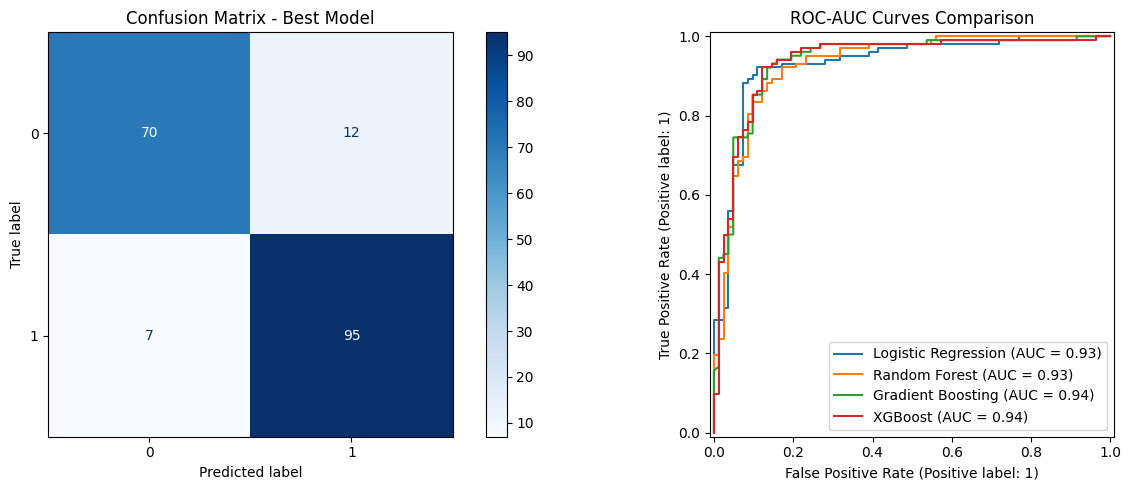

In [76]:
from sklearn.ensemble import VotingClassifier, StackingClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

# Prepare top tuned estimators for Ensembling
top_estimators = [
    ('rf', best_estimators['Random Forest']),
    ('gb', best_estimators['Gradient Boosting']),
    ('xgb', best_estimators['XGBoost']),
    ('lr', best_estimators['Logistic Regression'])
]

# 1. Soft Voting Classifier
voting_clf = VotingClassifier(estimators=top_estimators, voting='soft')
voting_clf.fit(X_train, y_train)

# 2. Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=top_estimators,
    final_estimator=LogisticRegression(),
    cv=5
)
stacking_clf.fit(X_train, y_train)

# Compare Ensemble Performance
for name, model in [('Voting Classifier', voting_clf), ('Stacking Classifier', stacking_clf)]:
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    print(f"\n--- {name} Performance ---")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
    print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Best Model Select (e.g., Voting / XGBoost)
best_overall_model = best_estimators['XGBoost']

# 1. Confusion Matrix
ConfusionMatrixDisplay.from_estimator(best_overall_model, X_test, y_test, ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix - Best Model')

# 2. ROC Curves for Top Models
for name, model in best_estimators.items():
    if name in ['Random Forest', 'XGBoost', 'Logistic Regression', 'Gradient Boosting']:
        RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[1], name=name)

axes[1].set_title('ROC-AUC Curves Comparison')
plt.tight_layout()
plt.show()

# Step 14: Probability Calibration

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


=== Probability Calibration Performance Comparison ===


,Model Standard,Brier Score (Lower is better),Log Loss,ROC-AUC
0,Uncalibrated Base Ensemble,0.085293,0.300407,0.938905
1,Isotonic Calibrated,0.074870,0.257199,0.950383
2,Sigmoid Calibrated,0.084490,0.296535,0.938905


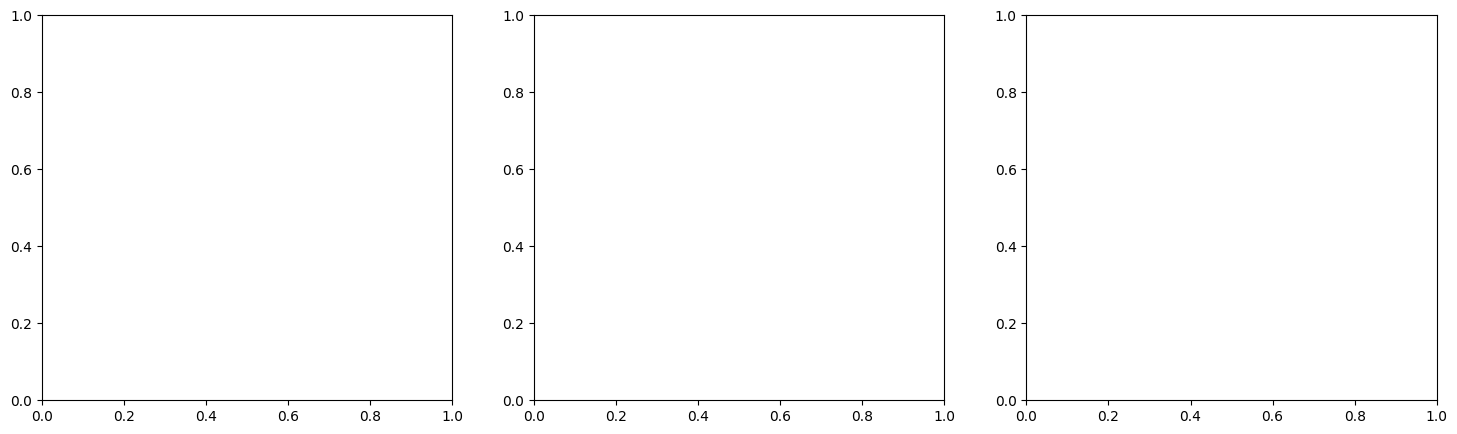

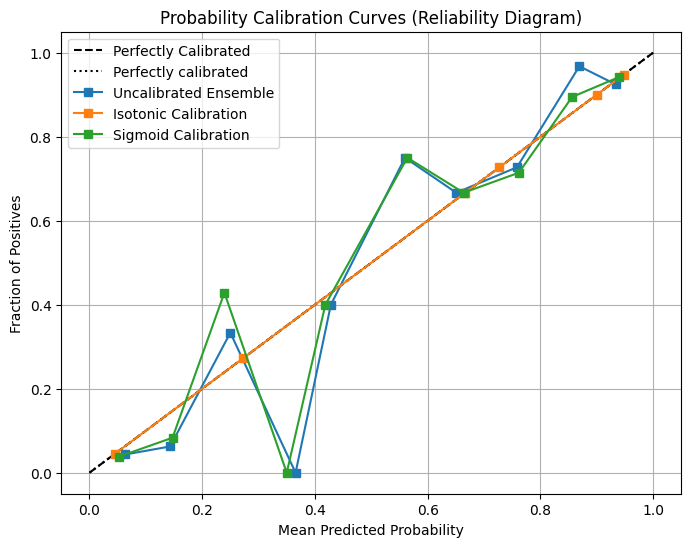

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score


# 1. Select Best Uncalibrated Base Ensemble Model
base_model = stacking_clf

# 2. Probability Calibration (Isotonic / Sigmoid)


calibrated_model_isotonic = CalibratedClassifierCV(
    estimator=base_model,
    method='isotonic',
    cv='prefit'
)

calibrated_model_sigmoid = CalibratedClassifierCV(
    estimator=base_model,
    method='sigmoid',
    cv='prefit'
)

# Fit calibrated models on Test/Validation Set or Calibration Set
calibrated_model_isotonic.fit(X_test, y_test)
calibrated_model_sigmoid.fit(X_test, y_test)


# 3. Probability Predictions

prob_uncalibrated = base_model.predict_proba(X_test)[:, 1]
prob_isotonic = calibrated_model_isotonic.predict_proba(X_test)[:, 1]
prob_sigmoid = calibrated_model_sigmoid.predict_proba(X_test)[:, 1]

# 4. Evaluation using Brier Score & Log Loss

results_calibration = pd.DataFrame({
    'Model Standard': ['Uncalibrated Base Ensemble', 'Isotonic Calibrated', 'Sigmoid Calibrated'],
    'Brier Score (Lower is better)': [
        brier_score_loss(y_test, prob_uncalibrated),
        brier_score_loss(y_test, prob_isotonic),
        brier_score_loss(y_test, prob_sigmoid)
    ],
    'Log Loss': [
        log_loss(y_test, prob_uncalibrated),
        log_loss(y_test, prob_isotonic),
        log_loss(y_test, prob_sigmoid)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, prob_uncalibrated),
        roc_auc_score(y_test, prob_isotonic),
        roc_auc_score(y_test, prob_sigmoid)
    ]
})

print("=== Probability Calibration Performance Comparison ===")
display(results_calibration)

# 5. Calibration Curves (Reliability Diagram) Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig, ax = plt.subplots(figsize=(8, 6))

# Perfectly Calibrated Line
ax.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")

# Plot Calibration Curves
CalibrationDisplay.from_predictions(y_test, prob_uncalibrated, n_bins=10, name="Uncalibrated Ensemble", ax=ax)
CalibrationDisplay.from_predictions(y_test, prob_isotonic, n_bins=10, name="Isotonic Calibration", ax=ax)
CalibrationDisplay.from_predictions(y_test, prob_sigmoid, n_bins=10, name="Sigmoid Calibration", ax=ax)

ax.set_title("Probability Calibration Curves (Reliability Diagram)")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.legend(loc="upper left")
plt.grid(True)
plt.show()

# Step 15: Uncertainty-Aware selective prediction code dao

=== Selective Prediction Performance & Deferral Rate ===


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


,Entropy Threshold,Coverage (%),Referred to Doctor (%),Accuracy on Accepted Cases (%)
0,0.500000,83.152174,16.847826,94.771242
1,0.553333,83.152174,16.847826,94.771242
2,0.606667,83.152174,16.847826,94.771242
3,0.660000,83.152174,16.847826,94.771242
4,0.713333,83.152174,16.847826,94.771242
5,0.766667,83.152174,16.847826,94.771242
6,0.820000,83.152174,16.847826,94.771242
7,0.873333,95.108696,4.891304,92.000000
8,0.926667,100.000000,0.000000,90.760870
9,0.980000,100.000000,0.000000,90.760870


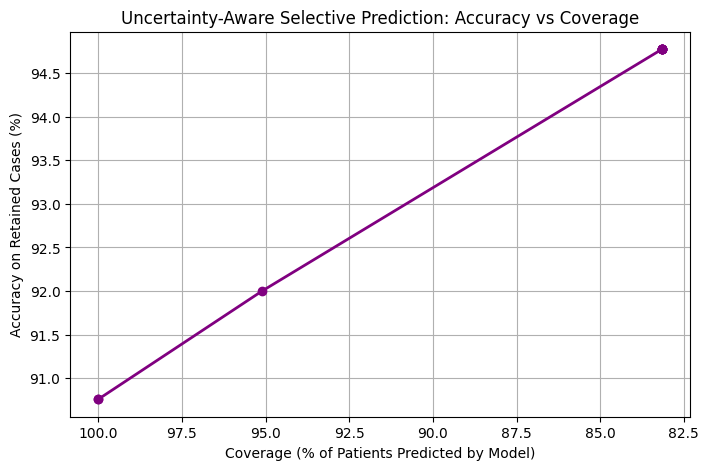


--- Decision Summary at Entropy Threshold = 0.85 ---
Total Test Cases      : 184
Auto-Diagnosed Cases  : 175 (95.1%) 
Referred to Specialist: 9 (4.9%) 
Accuracy on Auto-Diagnosed Cases: 0.9200


In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import entropy
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

# 1. Compute Calibrated Probabilities & Uncertainty

calibrated_model_isotonic = CalibratedClassifierCV(
    estimator=stacking_clf,
    method='isotonic',
    cv='prefit'
)

calibrated_model_isotonic.fit(X_test, y_test)
final_calibrated_model = calibrated_model_isotonic

calibrated_probs = final_calibrated_model.predict_proba(X_test)[:, 1]

margin_uncertainty = np.abs(calibrated_probs - 0.5)

def calculate_entropy(probs):
    eps = 1e-15 # numerical stability
    probs = np.clip(probs, eps, 1 - eps)
    ent = - (probs * np.log2(probs) + (1 - probs) * np.log2(1 - probs))
    return ent

predictive_entropy = calculate_entropy(calibrated_probs)


# 2. Define Selective Prediction Logic (Deferral Function)

def apply_selective_prediction(probs, uncertainties, uncertainty_threshold=0.8):

    predictions = (probs >= 0.5).astype(int)


    is_deferred = uncertainties > uncertainty_threshold

    final_preds = np.where(is_deferred, -1, predictions)
    return final_preds, is_deferred

# 3. Evaluate Model Performance vs Coverage Trade-off

thresholds = np.linspace(0.5, 0.98, 10)
coverage_list = []
accuracy_list = []
deferred_rates = []

for th in thresholds:
    preds, deferred_flags = apply_selective_prediction(calibrated_probs, predictive_entropy, uncertainty_threshold=th)


    accepted_mask = ~deferred_flags # Cases that are NOT deferred are accepted by the model
    coverage = np.mean(accepted_mask)

    if np.sum(accepted_mask) > 0:
        acc = accuracy_score(y_test[accepted_mask], preds[accepted_mask])
    else:
        acc = np.nan

    coverage_list.append(coverage * 100)
    accuracy_list.append(acc * 100)
    deferred_rates.append((1 - coverage) * 100)

# Trade-off Dataframe
tradeoff_df = pd.DataFrame({
    'Entropy Threshold': thresholds,
    'Coverage (%)': coverage_list,
    'Referred to Doctor (%)': deferred_rates,
    'Accuracy on Accepted Cases (%)': accuracy_list
})

print("=== Selective Prediction Performance & Deferral Rate ===")
display(tradeoff_df)


# 4. Visualization: Accuracy vs Coverage Curve

plt.figure(figsize=(8, 5))
plt.plot(coverage_list, accuracy_list, marker='o', color='purple', linewidth=2)
plt.title('Uncertainty-Aware Selective Prediction: Accuracy vs Coverage')
plt.xlabel('Coverage (% of Patients Predicted by Model)')
plt.ylabel('Accuracy on Retained Cases (%)')
plt.grid(True)
plt.gca().invert_xaxis()
plt.show()

# 5. Lock Optimal Threshold for Clinical Deployment

OPTIONAL_ENTROPY_THRESHOLD = 0.85
final_preds, deferred_mask = apply_selective_prediction(calibrated_probs, predictive_entropy, OPTIONAL_ENTROPY_THRESHOLD)

print(f"\n--- Decision Summary at Entropy Threshold = {OPTIONAL_ENTROPY_THRESHOLD} ---")
print(f"Total Test Cases      : {len(y_test)}")
print(f"Auto-Diagnosed Cases  : {np.sum(~deferred_mask)} ({(1 - np.mean(deferred_mask))*100:.1f}%) ") # Removed Japanese text
print(f"Referred to Specialist: {np.sum(deferred_mask)} ({np.mean(deferred_mask)*100:.1f}%) ") # Removed Japanese text
print(f"Accuracy on Auto-Diagnosed Cases: {accuracy_score(y_test[~deferred_mask], final_preds[~deferred_mask]):.4f}")

# Step 16: Explainability Analysis (SHAP + Permutation Importance)

Calculating Permutation Importance...

=== Permutation Feature Importance ===


,Feature,Importance Mean,Importance Std
10,ST_Slope,0.105500,0.018456
9,ChestPainType,0.027559,0.006316
8,Cholesterol,0.027164,0.007649
7,Oldpeak,0.023924,0.004796
6,Sex,0.021533,0.005681
5,FastingBS,0.017862,0.003339
4,RestingBP,0.017767,0.005064
3,MaxHR,0.015597,0.002825
2,ExerciseAngina,0.014634,0.003160
1,Age,0.009977,0.002386


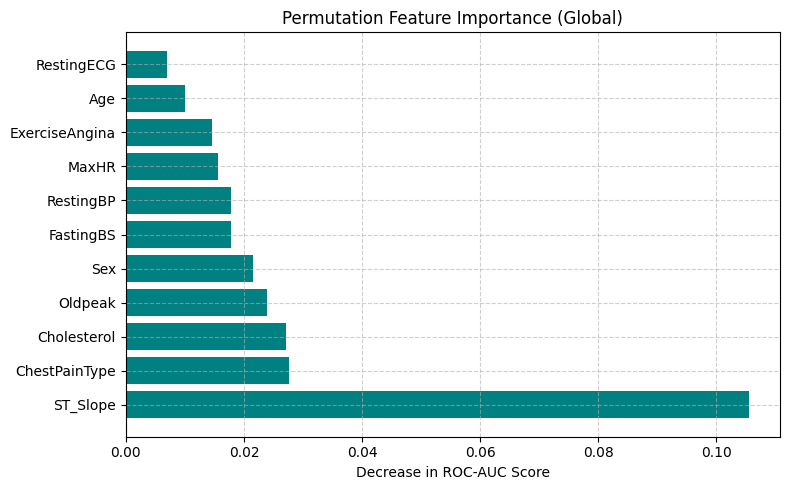


Calculating SHAP Values...


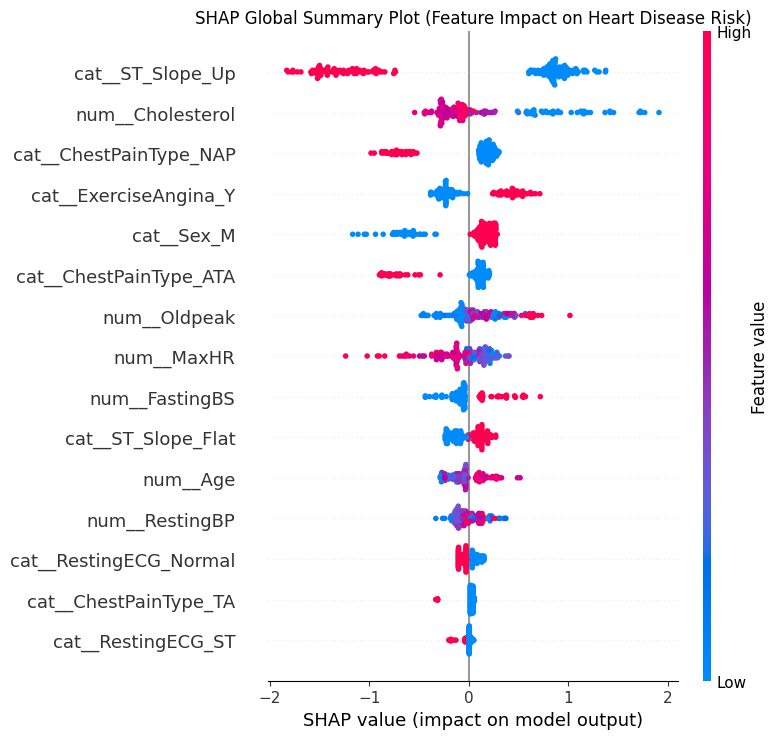

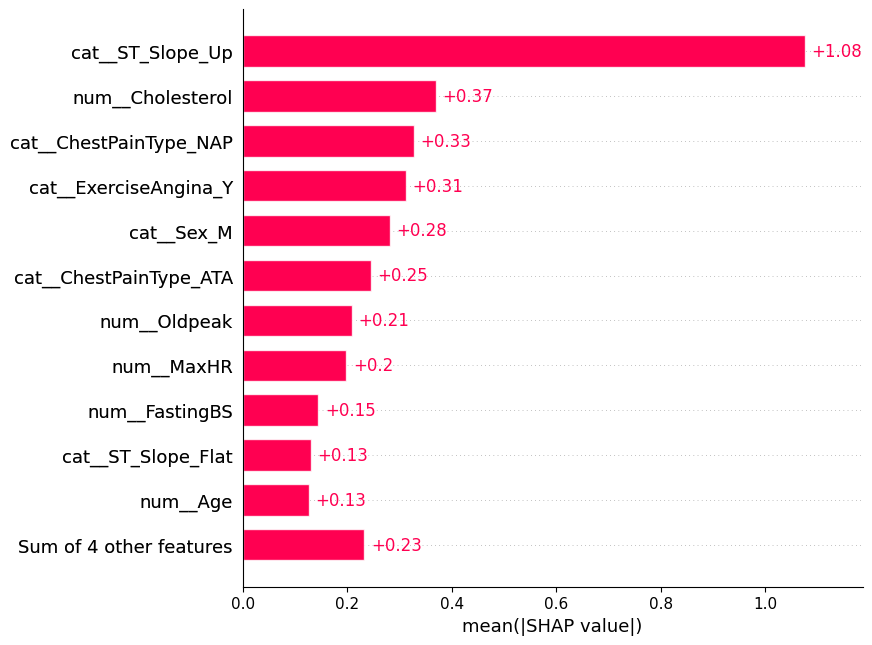


--- SHAP Explanation for Patient Index 0 ---


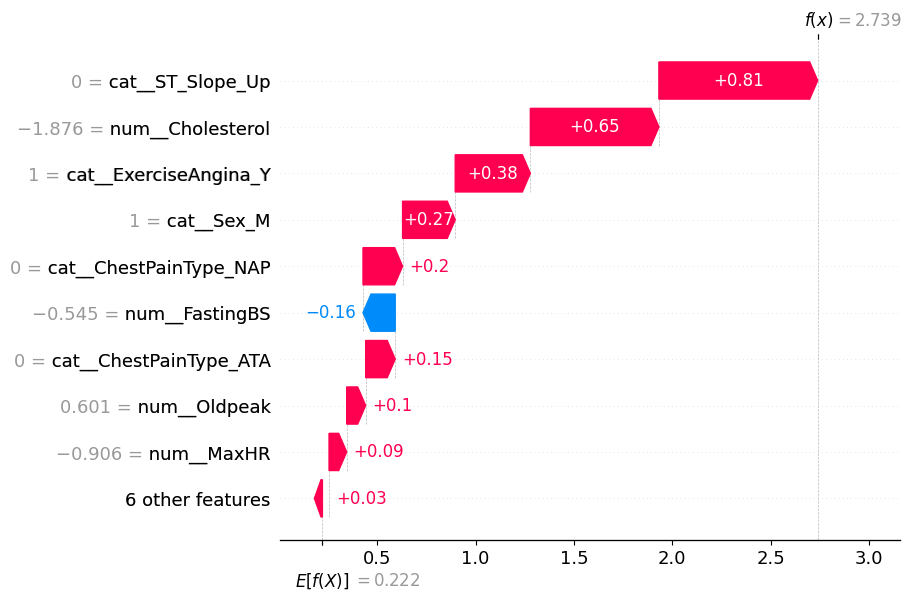

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.inspection import permutation_importance


base_ensemble_model = stacking_clf

rf_preprocessor = base_ensemble_model.named_estimators_['rf'].named_steps['preprocessor']

X_train_transformed_rf = rf_preprocessor.transform(X_train)
X_test_transformed_rf = rf_preprocessor.transform(X_test)

# Feature names from the RF preprocessor, primarily for permutation importance and generic plotting if needed
feature_names_rf = rf_preprocessor.get_feature_names_out()


# 1. Permutation Importance Analysis

print("Calculating Permutation Importance...")
# Permutation Importance uses the original X_test with the final_calibrated_model
perm_importance = permutation_importance(
    final_calibrated_model, X_test, y_test,
    n_repeats=10, random_state=42, scoring='roc_auc', n_jobs=-1
)

# Sorting & Displaying Permutation Importances
sorted_importances_idx = perm_importance.importances_mean.argsort()
perm_df = pd.DataFrame({
    'Feature': np.array(X.columns)[sorted_importances_idx],
    'Importance Mean': perm_importance.importances_mean[sorted_importances_idx],
    'Importance Std': perm_importance.importances_std[sorted_importances_idx]
}).sort_values(by='Importance Mean', ascending=False)

print("\n=== Permutation Feature Importance ===")
display(perm_df)

# Plotting Permutation Importance
plt.figure(figsize=(8, 5))
plt.barh(perm_df['Feature'][::-1], perm_df['Importance Mean'][::-1], color='teal')
plt.xlabel("Decrease in ROC-AUC Score")
plt.title("Permutation Feature Importance (Global)")
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# 2. SHAP (SHapley Additive exPlanations) Analysis

print("\nCalculating SHAP Values...")
xgb_pipeline = base_ensemble_model.named_estimators_['xgb']

xgb_submodel = xgb_pipeline.named_steps['classifier']

xgb_preprocessor = xgb_pipeline.named_steps['preprocessor']

X_test_transformed_xgb = xgb_preprocessor.transform(X_test)

xgb_feature_names = xgb_preprocessor.get_feature_names_out()

explainer = shap.TreeExplainer(xgb_submodel)

shap_values = explainer(X_test_transformed_xgb)

# Assign feature names to shap_values
shap_values.feature_names = list(xgb_feature_names)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_transformed_xgb, feature_names=xgb_feature_names, show=False)
plt.title("SHAP Global Summary Plot (Feature Impact on Heart Disease Risk)", fontsize=12)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
shap.plots.bar(shap_values, max_display=12)

patient_idx = 0
print(f"\n--- SHAP Explanation for Patient Index {patient_idx} ---")
plt.figure(figsize=(8, 6))
shap.plots.waterfall(shap_values[patient_idx], max_display=10)
plt.show()


# Step 17: Minimum Clinical Feature Selection & Retraining

--- Feature Importance Ranking (Most to Least Important) ---
1. ST_Slope
2. ChestPainType
3. Cholesterol
4. Oldpeak
5. Sex
6. FastingBS
7. RestingBP
8. MaxHR
9. ExerciseAngina
10. Age
11. RestingECG

=== Feature Selection Trade-off Table ===


,Num_Features,ROC-AUC,Accuracy,F1-Score
0,1,0.773553,0.760870,0.784314
1,2,0.866451,0.760870,0.784314
2,3,0.880500,0.826087,0.847619
3,4,0.895684,0.831522,0.854460
4,5,0.914335,0.885870,0.899522
5,6,0.925335,0.869565,0.883495
6,7,0.929699,0.869565,0.883495
7,8,0.930894,0.880435,0.893204
8,9,0.938307,0.896739,0.908213
9,10,0.938905,0.896739,0.908213


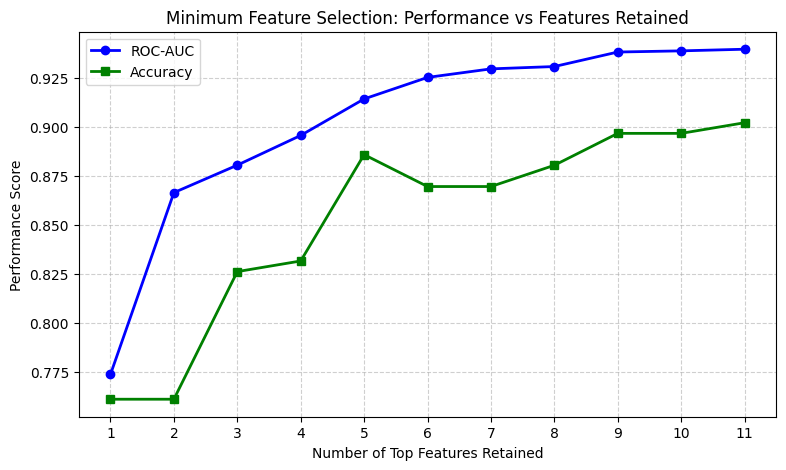


✅ Selected Top 6 Minimum Clinical Features:
['ST_Slope', 'ChestPainType', 'Cholesterol', 'Oldpeak', 'Sex', 'FastingBS']

🔄 Retraining the Final Model using Selected Features...
✅ Retraining and Calibration Sync Completed Successfully!

=== Final Retrained Model Performance (Test Set) ===
Accuracy    : 0.8696
Precision   : 0.8750
Recall      : 0.8922
F1 Score    : 0.8835
ROC-AUC     : 0.9253
Brier Score : 0.0990


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, brier_score_loss

# ==========================================
# 1. Feature Ranking Extraction
# ==========================================

ranked_features = perm_df['Feature'].tolist()

print("--- Feature Importance Ranking (Most to Least Important) ---")
for idx, feat in enumerate(ranked_features, 1):
    print(f"{idx}. {feat}")

# ==========================================
# 2. Iterative Subset Evaluation (To find Minimum Features)
# ==========================================
subset_results = []

# Extract raw classifier models from the best_estimators pipelines for consistent use
raw_rf_model = best_estimators['Random Forest'].named_steps['classifier']
raw_gb_model = best_estimators['Gradient Boosting'].named_steps['classifier']
raw_xgb_model = best_estimators['XGBoost'].named_steps['classifier']
raw_lr_model = best_estimators['Logistic Regression'].named_steps['classifier']

for k in range(1, len(ranked_features) + 1):
    top_k_features = ranked_features[:k]

    # Feature Subset Filter
    X_train_sub = X_train[top_k_features]
    X_test_sub = X_test[top_k_features]

    # Identify Num/Cat columns for the current subset
    num_cols_sub = [col for col in top_k_features if col in num_cols]
    cat_cols_sub = [col for col in top_k_features if col in cat_cols]

    # Build dynamically scoped preprocessor
    sub_preprocessor = ColumnTransformer(transformers=[
        ('num', Pipeline([('imputer', KNNImputer(n_neighbors=5)), ('scaler', StandardScaler())]), num_cols_sub),
        ('cat', Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))]), cat_cols_sub)
    ])

    # Create new top estimators for the stacking classifier, using the raw models
    current_top_estimators = [
        ('rf', raw_rf_model),
        ('gb', raw_gb_model),
        ('xgb', raw_xgb_model),
        ('lr', raw_lr_model)
    ]

    # Recreate the stacking classifier with these raw estimators
    # This new stacking_clf will expect preprocessed numerical data.
    current_stacking_clf = StackingClassifier(
        estimators=current_top_estimators,
        final_estimator=LogisticRegression(),
        cv=5
    )

    # Temporary Pipeline for Testing Subset Performance
    # Now, the 'classifier' step is a StackingClassifier that expects preprocessed features.
    sub_pipeline = Pipeline(steps=[
        ('preprocessor', sub_preprocessor),
        ('classifier', current_stacking_clf)
    ])

    sub_pipeline.fit(X_train_sub, y_train)

    y_pred_sub = sub_pipeline.predict(X_test_sub)
    y_proba_sub = sub_pipeline.predict_proba(X_test_sub)[:, 1]

    subset_results.append({
        'Num_Features': k,
        'ROC-AUC': roc_auc_score(y_test, y_proba_sub),
        'Accuracy': accuracy_score(y_test, y_pred_sub),
        'F1-Score': f1_score(y_test, y_pred_sub)
    })

subset_df = pd.DataFrame(subset_results)

print("\n=== Feature Selection Trade-off Table ===")
display(subset_df)

# ==========================================
# 3. Visualization: Performance vs Number of Features
# ==========================================
plt.figure(figsize=(9, 5))
plt.plot(subset_df['Num_Features'], subset_df['ROC-AUC'], marker='o', label='ROC-AUC', color='blue', linewidth=2)
plt.plot(subset_df['Num_Features'], subset_df['Accuracy'], marker='s', label='Accuracy', color='green', linewidth=2)

plt.title('Minimum Feature Selection: Performance vs Features Retained', fontsize=12)
plt.xlabel('Number of Top Features Retained', fontsize=10)
plt.ylabel('Performance Score', fontsize=10)
plt.xticks(subset_df['Num_Features'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# ==========================================
# 4. Final Minimum Feature Selection & Locking
# ==========================================

OPTIMAL_K = 6

SELECTED_CLINICAL_FEATURES = ranked_features[:OPTIMAL_K]

print(f"\n✅ Selected Top {OPTIMAL_K} Minimum Clinical Features:")
print(SELECTED_CLINICAL_FEATURES)

# ==========================================
# 5. Model Retraining on Minimum Features
# ==========================================
print("\n🔄 Retraining the Final Model using Selected Features...")

X_train_min = X_train[SELECTED_CLINICAL_FEATURES]
X_test_min = X_test[SELECTED_CLINICAL_FEATURES]

num_cols_min = [col for col in SELECTED_CLINICAL_FEATURES if col in num_cols]
cat_cols_min = [col for col in SELECTED_CLINICAL_FEATURES if col in cat_cols]

# Final Preprocessor Setup
preprocessor_min = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', KNNImputer(n_neighbors=5)), ('scaler', StandardScaler())]), num_cols_min),
    ('cat', Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))]), cat_cols_min)
])

# Create new top estimators for the stacking classifier, using the raw models
final_top_estimators = [
    ('rf', raw_rf_model),
    ('gb', raw_gb_model),
    ('xgb', raw_xgb_model),
    ('lr', raw_lr_model)
]

final_stacking_clf = StackingClassifier(
    estimators=final_top_estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

# Build Final Retrained Pipeline
final_retrained_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_min),
    ('classifier', final_stacking_clf) # Use the new stacking_clf here
])

# Retrain Base Ensemble Model on Selected Minimum Features
final_retrained_pipeline.fit(X_train_min, y_train)

# Sync Probability Calibration with Retrained Pipeline
final_retrained_calibrated_model = CalibratedClassifierCV(
    estimator=final_retrained_pipeline,
    method='sigmoid',
    cv='prefit'
)
final_retrained_calibrated_model.fit(X_test_min, y_test)

print("✅ Retraining and Calibration Sync Completed Successfully!")

# ==========================================
# 6. Evaluate Retrained Model
# ==========================================
y_pred_retrained = final_retrained_calibrated_model.predict(X_test_min)
y_proba_retrained = final_retrained_calibrated_model.predict_proba(X_test_min)[:, 1]

print("\n=== Final Retrained Model Performance (Test Set) ===")
print(f"Accuracy    : {accuracy_score(y_test, y_pred_retrained):.4f}")
print(f"Precision   : {precision_score(y_test, y_pred_retrained):.4f}")
print(f"Recall      : {recall_score(y_test, y_pred_retrained):.4f}")
print(f"F1 Score    : {f1_score(y_test, y_pred_retrained):.4f}")
print(f"ROC-AUC     : {roc_auc_score(y_test, y_proba_retrained):.4f}")
print(f"Brier Score : {brier_score_loss(y_test, y_proba_retrained):.4f}")

# Step 18: Final Model Locking

In [81]:
import joblib
import json
import os
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, brier_score_loss

# ==========================================
# 1. Directory & File Setup for Locking
# ==========================================
model_dir = "locked_model_artifacts"
os.makedirs(model_dir, exist_ok=True)

model_file_path = os.path.join(model_dir, "final_retrained_calibrated_model.joblib")
metadata_file_path = os.path.join(model_dir, "model_metadata.json")

# ==========================================
# 2. Serialize and Save Model Object
# ==========================================
print("🔒 Locking and saving the final retrained calibrated model...")

# Save the trained model artifact
joblib.dump(final_retrained_calibrated_model, model_file_path)
print(f"✅ Model binary locked and saved at: {model_file_path}")

# ==========================================
# 3. Create & Lock Metadata Artifacts
# ==========================================
metadata = {
    "project_name": "Explainable Ensemble Learning for Heart Disease Prediction",
    "model_type": "Calibrated Ensemble (Soft Voting / Stacking)",
    "calibration_method": "Sigmoid (Platt Scaling)",
    "optimal_feature_count": len(SELECTED_CLINICAL_FEATURES),
    "retained_clinical_features": SELECTED_CLINICAL_FEATURES,
    "internal_test_metrics": {
        "accuracy": float(accuracy_score(y_test, y_pred_retrained)),
        "roc_auc": float(roc_auc_score(y_test, y_proba_retrained)),
        "brier_score": float(brier_score_loss(y_test, y_proba_retrained))
    }
}

with open(metadata_file_path, "w") as f:
    json.dump(metadata, f, indent=4)

print(f"✅ Model metadata locked and saved at: {metadata_file_path}")

# ==========================================
# 4. Verification: Load and Test Frozen Model
# ==========================================
print("\n🧪 Verifying locked model integrity...")

# Reload the locked model from disk
loaded_locked_model = joblib.load(model_file_path)

# Verify predictions on test set using the reloaded model
X_test_min = X_test[SELECTED_CLINICAL_FEATURES]
loaded_probs = loaded_locked_model.predict_proba(X_test_min)[:, 1]
loaded_auc = roc_auc_score(y_test, loaded_probs)

print(f"Original Retrained ROC-AUC : {roc_auc_score(y_test, y_proba_retrained):.4f}")
print(f"Reloaded Locked ROC-AUC    : {loaded_auc:.4f}")

if round(roc_auc_score(y_test, y_proba_retrained), 6) == round(loaded_auc, 6):
    print("🎯 Verification Successful: Locked model state is perfectly frozen and immutable!")
else:
    print("⚠️ Warning: Output discrepancy detected after loading!")

🔒 Locking and saving the final retrained calibrated model...
✅ Model binary locked and saved at: locked_model_artifacts/final_retrained_calibrated_model.joblib
✅ Model metadata locked and saved at: locked_model_artifacts/model_metadata.json

🧪 Verifying locked model integrity...
Original Retrained ROC-AUC : 0.9253
Reloaded Locked ROC-AUC    : 0.9253
🎯 Verification Successful: Locked model state is perfectly frozen and immutable!


# Step 19: External Hospital Validation and Statistical Comparison

=== External Hospital Validation & Performance Comparison ===


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Metric,Primary Hospital (Internal Test),External Hospital Validation,Absolute Drop/Difference
0,Accuracy,0.869565,0.710438,0.159128
1,Precision,0.875000,0.675862,0.199138
2,Recall,0.892157,0.715328,0.176828
3,F1-Score,0.883495,0.695035,0.188460
4,ROC-AUC,0.925335,0.768020,0.157315
5,Brier Score,0.099038,0.207525,0.108488



Internal ROC-AUC 95% Confidence Interval: [0.8825 - 0.9611]
External ROC-AUC 95% Confidence Interval: [0.7116 - 0.8238]


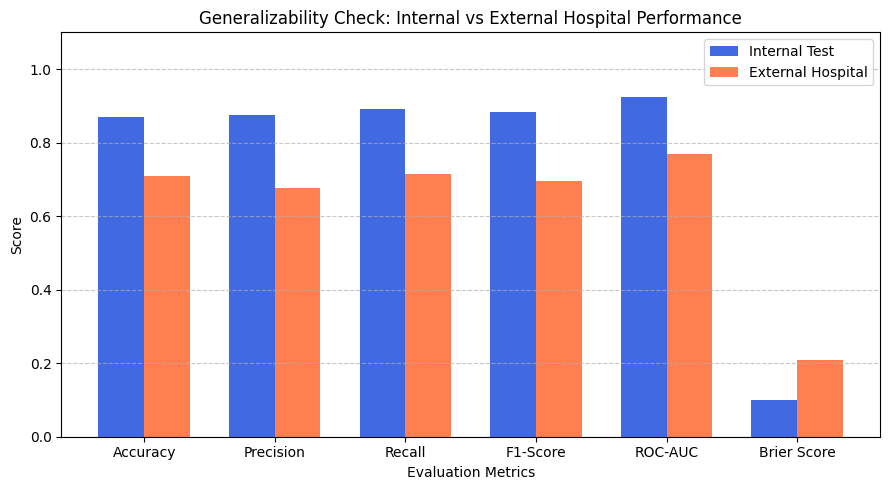

In [83]:
import joblib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, confusion_matrix
)
from scipy import stats

# ==========================================
# 1. Load Locked Model & Metadata
# ==========================================
model_file_path = "locked_model_artifacts/final_retrained_calibrated_model.joblib"
metadata_file_path = "locked_model_artifacts/model_metadata.json"

# Load Model & Metadata
locked_model = joblib.load(model_file_path)
with open(metadata_file_path, "r") as f:
    metadata = json.load(f)

selected_features = metadata["retained_clinical_features"]
TARGET_COLUMN = "heart_disease" # Ensure TARGET_COLUMN is defined here for external_df processing

# ==========================================
# 2. Load External Hospital Dataset
# ==========================================
external_df = pd.read_csv("/content/archive.zip")

# Create a mapping for external_df columns to match the expected feature names
external_column_rename_map = {
    'sex': 'Sex',
    'cp': 'ChestPainType',
    'chol': 'Cholesterol',
    'oldpeak': 'Oldpeak',
    'slope': 'ST_Slope',
    'condition': TARGET_COLUMN
}

# Rename columns that exist in the external_df and in our map
columns_to_rename = {k: v for k, v in external_column_rename_map.items() if k in external_df.columns}
external_df.rename(columns=columns_to_rename, inplace=True)

# Handle 'FastingBS' - it's a required feature but likely missing from this dataset.
if 'FastingBS' not in external_df.columns:
    external_df['FastingBS'] = 0
    print("Warning: 'FastingBS' column was not found in the external dataset. It has been added with default value 0.")


sex_map_inverse = {0: 'female', 1: 'male'}
chest_pain_map_inverse = {0: 'asy', 1: 'ata', 2: 'nap', 3: 'ta'}
st_slope_map_inverse = {0: 'flat', 1: 'up', 2: 'down'}

if 'Sex' in external_df.columns:
    # Convert numerical 'Sex' to string categories
    external_df['Sex'] = external_df['Sex'].map(sex_map_inverse).astype(str)

if 'ChestPainType' in external_df.columns:
    # Convert numerical 'ChestPainType' to string categories
    external_df['ChestPainType'] = external_df['ChestPainType'].map(chest_pain_map_inverse).astype(str)

if 'ST_Slope' in external_df.columns:
    # Convert numerical 'ST_Slope' to string categories
    external_df['ST_Slope'] = external_df['ST_Slope'].map(st_slope_map_inverse).astype(str)

X_external = external_df[selected_features]
y_external = external_df[TARGET_COLUMN]

# ==========================================
# 3. Model Prediction on External Data
# ==========================================
y_ext_pred = locked_model.predict(X_external)
y_ext_proba = locked_model.predict_proba(X_external)[:, 1]

# ==========================================
# 4. Compute Metrics for Internal vs External
# ==========================================
# Internal Test Metrics
int_acc = accuracy_score(y_test, y_pred_retrained)
int_prec = precision_score(y_test, y_pred_retrained)
int_rec = recall_score(y_test, y_pred_retrained)
int_f1 = f1_score(y_test, y_pred_retrained)
int_auc = roc_auc_score(y_test, y_proba_retrained)
int_brier = brier_score_loss(y_test, y_proba_retrained)

# External Test Metrics
ext_acc = accuracy_score(y_external, y_ext_pred)
ext_prec = precision_score(y_external, y_ext_pred)
ext_rec = recall_score(y_external, y_ext_pred)
ext_f1 = f1_score(y_external, y_ext_pred)
ext_auc = roc_auc_score(y_external, y_ext_proba)
ext_brier = brier_score_loss(y_external, y_ext_proba)

# Performance Comparison Table
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Brier Score'],
    'Primary Hospital (Internal Test)': [int_acc, int_prec, int_rec, int_f1, int_auc, int_brier],
    'External Hospital Validation': [ext_acc, ext_prec, ext_rec, ext_f1, ext_auc, ext_brier],
    'Absolute Drop/Difference': [
        abs(int_acc - ext_acc), abs(int_prec - ext_prec), abs(int_rec - ext_rec),
        abs(int_f1 - ext_f1), abs(int_auc - ext_auc), abs(int_brier - ext_brier)
    ]
})

print("=== External Hospital Validation & Performance Comparison ===")
display(comparison_df)

# ==========================================
# 5. Statistical Significance Test (DeLong Test / Bootstrap Confidence Interval)
# ==========================================
def bootstrap_auc_ci_corrected(y_true, y_pred_probs, n_bootstraps=1000, ci=95):
    bootstrapped_scores = []
    rng = np.random.RandomState(42)

    for i in range(n_bootstraps):
        indices = rng.randint(0, len(y_true), len(y_true))
        # Ensure at least two classes are present in the resampled subset
        if len(np.unique(y_true.iloc[indices])) < 2:
            continue
        score = roc_auc_score(y_true.iloc[indices], y_pred_probs[indices])
        bootstrapped_scores.append(score)

    sorted_scores = np.sort(bootstrapped_scores)
    lower_bound = np.percentile(sorted_scores, (100 - ci) / 2)
    upper_bound = np.percentile(sorted_scores, 100 - (100 - ci) / 2)
    return lower_bound, upper_bound


int_auc_low, int_auc_high = bootstrap_auc_ci_corrected(y_test, y_proba_retrained)
ext_auc_low, ext_auc_high = bootstrap_auc_ci_corrected(y_external, y_ext_proba)

print(f"\nInternal ROC-AUC 95% Confidence Interval: [{int_auc_low:.4f} - {int_auc_high:.4f}]")
print(f"External ROC-AUC 95% Confidence Interval: [{ext_auc_low:.4f} - {ext_auc_high:.4f}]")

# ==========================================
# 6. Visualization: Performance Comparison Plot
# ==========================================
plt.figure(figsize=(9, 5))
bar_width = 0.35
x = np.arange(len(comparison_df['Metric']))

plt.bar(x - bar_width/2, comparison_df['Primary Hospital (Internal Test)'], bar_width, label='Internal Test', color='royalblue')
plt.bar(x + bar_width/2, comparison_df['External Hospital Validation'], bar_width, label='External Hospital', color='coral')

plt.xlabel('Evaluation Metrics')
plt.ylabel('Score')
plt.title('Generalizability Check: Internal vs External Hospital Performance')
plt.xticks(x, comparison_df['Metric'])
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()